# 다이소 뷰티의 지속 소비 구조: 연착륙 분석 (Abstract)

- 본 연구는 다이소 뷰티 제품의 성과를  
  단기 판매 폭발이 아닌 **지속 소비 구조(연착륙)** 관점에서 재해석하고자 하였다.

- 히트 이후 0~12개월(rel_month) 구간의 리뷰 142,474건과  
  194개 SKU를 분석하여,  
  시간이 지나도 소비 신호가 유지되는 제품의 구조적 특징을 비교하였다.

- 분석 결과,
  - 히트 후보 중 **24.5%(48개)**만이 연착륙에 해당
  - 다수의 제품은 초기 폭발 이후 빠르게 관심이 감소

- 연착륙 제품은 다음과 같은 특성을 보였다:
  - 재구매율 유의하게 높음 (0.308 vs 0.248)
  - 평균 가격 더 높음 (4,500원 vs 3,510원)
  - 좋아요 수 높음
  - 리뷰 수·평점 차이는 통계적으로 유의하지 않음

- 카테고리 구조 측면에서,
  - 연착륙 제품의 **83.3%가 스킨케어**
  - 그중 **기초 스킨케어 비중 70.8%**
  - 색조·팩 중심 제품은 단기 소모형에 가까움

- 가격대 분석 결과,
  - 연착륙의 **75%가 Premium(High) 가격대**
  - 저가 Easy Pick 제품에서는 연착륙 사례 거의 없음

- 리뷰 언어 분석에서는
  - “계속”, “재구매”, “번째”, “항상” 등  
    사용 지속성을 암시하는 표현이 시간 경과 후에도 유지됨

- 종합하면,
  다이소의 성장은 단발성 바이럴의 축적이 아니라  
  **‘납득 가능한 품질을 갖춘 스킨케어 제품의 반복 사용 구조’** 에 의해 설명될 가능성이 높다.

- 이는
  “많이 팔린 제품”과 “오래 사용된 제품”을 구분하여  
  전략적으로 관리할 필요성을 시사한다.

## 1. 환경 설정

In [ ]:
import sys
import importlib
import os
from pathlib import Path

PROJECT_ROOT = Path(r"G:/Final_proj/Total_clear/데이터")
DATA_DIR = PROJECT_ROOT / "data"
ANALYSIS_DIR = DATA_DIR / "analysis"
INGRED_DIR = DATA_DIR / "ingred"
UTILS_DIR = DATA_DIR / "pop" / "utils"

if str(UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(UTILS_DIR))

for module_name in ["keyword_analysis", "text_preprocessing", "visualization"]:
    if module_name in sys.modules:
        del sys.modules[module_name]

import keyword_analysis as ka
importlib.reload(ka)

print("프로젝트 루트:", PROJECT_ROOT)
print("MODULE PATH:", os.path.abspath(ka.__file__))
print("연착륙:", "연착륙" in ka.KEYWORD_CATEGORIES, len(ka.KEYWORD_CATEGORIES.get("연착륙", [])))


MODULE PATH: /Users/younghokim/Desktop/내배캠/최종 프로젝트/RQ/utils/keyword_analysis.py
연착륙: True 29


In [ ]:
# 라이브러리 import
import pandas as pd
import numpy as np
from scipy import stats
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

from text_preprocessing import extract_repurchase_flag, preprocess_text, tokenize_reviews
import keyword_analysis as ka
from visualization import (
    create_wordcloud,
    plot_keyword_comparison,
    plot_category_comparison,
    create_comparison_wordclouds,
    plot_grouped_bar,
    plot_rating_distribution,
)


In [127]:
# 스타일 및 한글 폰트 설정
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"설정 완료: {plt.rcParams['font.family']}")


설정 완료: ['Noto Sans KR']


## 2. 데이터 로드

In [ ]:
# 리뷰 데이터 로드
df_products = pd.read_parquet(ANALYSIS_DIR / "products_full.parquet").rename(columns={"brand_name": "brand"})
df_reviews = pd.read_parquet(ANALYSIS_DIR / "reviews_full.parquet")

print(f"[데이터 로드 완료]")
print(f"총 리뷰 수: {len(df_reviews):,}개")
print(f"총 상품 수: {len(df_products):,}개")


[데이터 로드 완료]
총 리뷰 수: 323,114개
컬럼: ['review_id', 'product_code', 'user_id', 'rating', 'review_date', 'text', 'review_length', 'image_count', 'is_reorder', 'promotion_id']

[샘플 데이터]


,review_id,product_code,user_id,rating,review_date,text,review_length,image_count,is_reorder,promotion_id
0,1,1048275,1,5.0,2024-01-01,다크 커버하려고 구매했어요 엄청 잘 가려지는 느낌은 아니지만 무난해요,38,0,False,NaN
1,2,1049275,2,5.0,2024-01-01,오픈런 할 자신은 없어서 재고 있을때 운좋게 구매했어요 전 넘 잘맞아서 진짜 쟁이고...,55,0,False,NaN
2,3,1049275,3,5.0,2024-01-01,재구매 운좋게 재구매해서 사용중입니다\n지금은 늘~ 품절이라 구매 어려워요 ㅠ\n제...,104,0,True,NaN
3,4,1049276,3,5.0,2024-01-01,재구매 약간 따끔하지만 참을만 합니다\n건성피부인데 촉촉해져서 기분이 좋아요~\n자...,59,0,True,NaN
4,5,1048273,4,5.0,2024-01-02,너무 만족해서 다른 컬러로 또 구매했어요,22,0,False,NaN


In [ ]:
# print(f"총 상품 수: {len(df_products):,}개")
# print(f"컬럼: {df_products.columns.tolist()}")
# print(f"\n[샘플 데이터_상품]")
# df_products.head()

총 상품 수: 954개
컬럼: ['Unnamed: 0', 'product_code', 'category_home', 'category_1', 'category_2', 'brand', 'name', 'price', 'country', 'likes', 'shares', 'group', 'review_count', 'engagement_score', 'price_tier', 'relative_price_ratio', 'price_position', 'cp_index', 'is_god_sung_bi', 'review_density', 'functional', 'ENTP_NAME', 'ITEM_PH', 'whitening', 'wrinkle_reduction', 'sunscreen']

[샘플 데이터_상품]


,Unnamed: 0,product_code,category_home,category_1,category_2,brand,name,price,country,likes,...,price_position,cp_index,is_god_sung_bi,review_density,functional,ENTP_NAME,ITEM_PH,whitening,wrinkle_reduction,sunscreen
0,0,1056665,뷰티/위생,스킨케어,기초스킨케어,해서린,해서린 스팟 케어 클리어 젤 10 ml,3000,한국,2814,...,Cheaper than Avg,184.166667,False,0.079602,1.0,디와이디,5.3,1,0,0
1,1,1061468,뷰티/위생,메이크업,베이스메이크업,드롭비,[04 커버 베이지] 드롭비 컬러즈 컨실팟,3000,한국,188,...,Cheaper than Avg,39.666667,False,0.872340,0.0,더샘인터내셔날,None,0,0,0
2,2,1061451,뷰티/위생,메이크업,치크/하이라이터,드롭비,[04 쉐딩 브론저] 드롭비 컬러즈쉐딩스틱,5000,한국,2731,...,More Expensive than Avg,110.590000,False,0.086415,0.0,더샘인터내셔날,None,0,0,0
3,3,1061454,뷰티/위생,메이크업,베이스메이크업,드롭비,[03 살몬 베이지] 드롭비 컬러즈 컨실팟,3000,한국,403,...,Cheaper than Avg,61.033333,False,0.538462,0.0,더샘인터내셔날,None,0,0,0
4,4,1061450,뷰티/위생,메이크업,치크/하이라이터,드롭비,[03 블러셔 로지 베리] 드롭비 컬러즈 블러셔 스틱,5000,한국,1330,...,More Expensive than Avg,48.640000,False,0.051128,0.0,더샘인터내셔날,None,0,0,0


In [130]:
# 기본 통계
print("[리뷰 데이터 기본 통계]")
print(f"평균 평점: {df_reviews['rating'].mean():.2f}")
print(f"리뷰 기간: {df_reviews['review_date'].min()} ~ {df_reviews['review_date'].max()}")
print(f"고유 제품 수: {df_reviews['product_code'].nunique():,}개")
print(f"고유 사용자 수: {df_reviews['user_id'].nunique():,}명")

[리뷰 데이터 기본 통계]
평균 평점: 4.74
리뷰 기간: 2024-01-01 ~ 2026-02-10
고유 제품 수: 937개
고유 사용자 수: 25,531명


In [131]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 323114 entries, 0 to 323113
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   review_id      323114 non-null  int64  
 1   product_code   323114 non-null  int64  
 2   user_id        323114 non-null  int64  
 3   rating         323114 non-null  float64
 4   review_date    323114 non-null  object 
 5   text           323037 non-null  object 
 6   review_length  323114 non-null  int64  
 7   image_count    323114 non-null  int64  
 8   is_reorder     323114 non-null  bool   
 9   promotion_id   24847 non-null   float64
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 22.5+ MB


## 3. 텍스트 전처리 및 토큰화

In [132]:
# 텍스트 토큰화
print("[텍스트 토큰화 시작]")

df_reviews['tokens'] = tokenize_reviews(
    df_reviews['text'].tolist(),
    extract_pos=['Noun', 'Adjective'],
    remove_stop=True,
    verbose=True
)

print("\n토큰화 완료")

[텍스트 토큰화 시작]
진행중: 1000/323114 (0.3%)
진행중: 2000/323114 (0.6%)
진행중: 3000/323114 (0.9%)
진행중: 4000/323114 (1.2%)
진행중: 5000/323114 (1.5%)
진행중: 6000/323114 (1.9%)
진행중: 7000/323114 (2.2%)
진행중: 8000/323114 (2.5%)
진행중: 9000/323114 (2.8%)
진행중: 10000/323114 (3.1%)
진행중: 11000/323114 (3.4%)
진행중: 12000/323114 (3.7%)
진행중: 13000/323114 (4.0%)
진행중: 14000/323114 (4.3%)
진행중: 15000/323114 (4.6%)
진행중: 16000/323114 (5.0%)
진행중: 17000/323114 (5.3%)
진행중: 18000/323114 (5.6%)
진행중: 19000/323114 (5.9%)
진행중: 20000/323114 (6.2%)
진행중: 21000/323114 (6.5%)
진행중: 22000/323114 (6.8%)
진행중: 23000/323114 (7.1%)
진행중: 24000/323114 (7.4%)
진행중: 25000/323114 (7.7%)
진행중: 26000/323114 (8.0%)
진행중: 27000/323114 (8.4%)
진행중: 28000/323114 (8.7%)
진행중: 29000/323114 (9.0%)
진행중: 30000/323114 (9.3%)
진행중: 31000/323114 (9.6%)
진행중: 32000/323114 (9.9%)
진행중: 33000/323114 (10.2%)
진행중: 34000/323114 (10.5%)
진행중: 35000/323114 (10.8%)
진행중: 36000/323114 (11.1%)
진행중: 37000/323114 (11.5%)
진행중: 38000/323114 (11.8%)
진행중: 39000/323114 (12.1%)
진행중: 40000/323

In [133]:
# 토큰화 결과 샘플 확인
print("[토큰화 결과 샘플]")
for idx in range(5):
    print(f"\n원문: {df_reviews.iloc[idx]['text'][:80]}")
    print(f"토큰: {df_reviews.iloc[idx]['tokens'][:20]}")

[토큰화 결과 샘플]

원문: 다크 커버하려고 구매했어요 엄청 잘 가려지는 느낌은 아니지만 무난해요
토큰: ['다크', '커버', '구매', '느낌', '아니다', '무난']

원문: 오픈런 할 자신은 없어서 재고 있을때 운좋게 구매했어요 전 넘 잘맞아서 진짜 쟁이고 싶은 상품이예요
토큰: ['오픈', '자신', '없다', '재고', '좋다', '구매', '잘맞다', '상품']

원문: 재구매 운좋게 재구매해서 사용중입니다
지금은 늘~ 품절이라 구매 어려워요 ㅠ
제가 사용해보고 좋아서 아들도 같이 사용중입니다
저는 300, 아들
토큰: ['좋다', '사용', '지금', '품절', '구매', '어렵다', '사용', '좋다', '아들', '사용', '아들', '자주']

원문: 재구매 약간 따끔하지만 참을만 합니다
건성피부인데 촉촉해져서 기분이 좋아요~
자주 구매할수 있으면 좋겠어요
토큰: ['약간', '따끔하다', '건성', '피부', '촉촉하다', '기분', '좋다', '자주', '구매', '좋다']

원문: 너무 만족해서 다른 컬러로 또 구매했어요
토큰: ['만족하다', '다른', '컬러', '구매']


## 4. 연착륙 정의
 * 리뷰: 연착륙 키워드 사전 중 하나라도 포함한다면 연착륙을 암시하는 리뷰로 봄
 * 시간: 첫 리뷰로부터 12개월 이내, 최소 관측 4개월 이상 (연착륙을 판별할 수 없는 최근 상품은 빠짐)
 * 상승폭: 0~2개월 대비 후반 6~12개월 연착륙암시비율이 0.01 이상이면 연착륙으로 판별

In [ ]:
tqdm.pandas(desc="리뷰 카테고리 매칭 중", mininterval=1.0)

def build_review_category_matrix_regex_fast(df_reviews, text_col='text', keyword_dict=None):
    if keyword_dict is None:
        keyword_dict = ka.KEYWORD_CATEGORIES

    compiled = {
        cat: [re.compile(p) for p in patterns]
        for cat, patterns in keyword_dict.items()
    }

    def _count_matches(text: str):
        out = {}
        for cat, regs in compiled.items():
            cnt = 0
            for rgx in regs:
                cnt += sum(1 for _ in rgx.finditer(text))
            out[cat] = cnt
        return out

    rows = (
        df_reviews[text_col]
        .fillna('')
        .astype(str)
        .progress_apply(_count_matches)
    )

    return pd.DataFrame(rows.tolist())

# 1) 카테고리 매트릭스 생성
df_cat = build_review_category_matrix_regex_fast(
    df_reviews,
    text_col='text',
    keyword_dict=ka.KEYWORD_CATEGORIES
)

# 2) 원본 + 카테고리 결합
df = pd.concat([df_reviews.reset_index(drop=True), df_cat.reset_index(drop=True)], axis=1)

# 3) 리뷰 단위 연착륙 플래그 (키워드 1회 이상이면 1)
#    - 이름을 명확히 하기 위해 review 플래그로 분리
df['is_softlanding_review'] = (df['연착륙'] > 0).astype(int)

print("[리뷰 단위 연착륙(키워드 매칭) 비율]")
display(
    pd.DataFrame({
        "리뷰수": df['is_softlanding_review'].value_counts().rename(index={0:'비연착륙', 1:'연착륙'}),
        "비중": df['is_softlanding_review'].value_counts(normalize=True).rename(index={0:'비연착륙', 1:'연착륙'}).round(4)
    })
)

print("\n[요약]")
print(f"리뷰 단위에서 '연착륙' 키워드가 1회 이상 등장한 리뷰 비중은 {df['is_softlanding_review'].mean():.4f}이다.")

리뷰 카테고리 매칭 중: 100%|██████████| 323114/323114 [00:44<00:00, 7337.11it/s]


[리뷰 단위 연착륙(키워드 매칭) 비율]


,리뷰수,비중
is_softlanding_review,,
비연착륙,319531,0.9889
연착륙,3583,0.0111



[요약]
리뷰 단위에서 '연착륙' 키워드가 1회 이상 등장한 리뷰 비중은 0.0111이다.
이 값은 '리뷰가 연착륙 맥락을 암시하는지'를 나타내며, SKU의 연착륙 성공 여부와는 별개로 취급하는 것이 안전하다.


In [136]:

# date 타입 보정
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# SKU별 첫 리뷰일 계산
first_date = df.groupby('product_code')['review_date'].min()

# 기존 first_date 컬럼이 있으면 삭제(충돌 방지)
if 'first_date' in df.columns:
    df = df.drop(columns=['first_date'])

# 붙이기 (merge가 가장 명확)
df = df.merge(
    first_date.rename('first_date').reset_index(),
    on='product_code',
    how='left'
)

# 연-월 정수화 후 rel_month 계산
ym = df['review_date'].dt.year * 12 + df['review_date'].dt.month
ym0 = df['first_date'].dt.year * 12 + df['first_date'].dt.month

df['rel_month'] = (ym - ym0).astype('Int64')

print("[rel_month 생성/확인]")
print("rel_month 범위:", int(df['rel_month'].min()), "~", int(df['rel_month'].max()))

[rel_month 생성/확인]
rel_month 범위: 0 ~ 25


In [13]:
# =============================
# 1) post(0~12개월) 구간만 사용
# =============================
MAX_MONTH = 12

df_post = df[df['rel_month'].between(0, MAX_MONTH)].copy()

print("[post 구간 데이터 요약]")
print("rel_month 범위:", int(df_post['rel_month'].min()), "~", int(df_post['rel_month'].max()))
print("post 구간 리뷰 수:", len(df_post))
print("post 구간 SKU 수:", df_post['product_code'].nunique())

# (옵션) date 결측 확인
print("\n[date 결측 점검]")
print("date 결측(NaT) 비율:", round(df_post['date'].isna().mean(), 4))

[post 구간 데이터 요약]
rel_month 범위: 0 ~ 12
post 구간 리뷰 수: 222124
post 구간 SKU 수: 853

[date 결측 점검]
date 결측(NaT) 비율: 0.0


In [137]:
# =============================
# 2) SKU-월별 연착륙 암시 비율(soft_ratio) 집계
#    - 리뷰 단위: is_softlanding_review (이미 생성되어 있어야 함)
# =============================

# 컬럼명 안전장치: 기존에 is_softlanding을 쓰고 있었다면 자동 변환
if 'is_softlanding_review' not in df_post.columns and 'is_softlanding' in df_post.columns:
    df_post['is_softlanding_review'] = df_post['is_softlanding'].astype(int)

sku_month_soft = (
    df_post
    .groupby(['product_code', 'rel_month'])
    .agg(
        월리뷰수=('is_softlanding_review', 'size'),
        연착륙암시비율=('is_softlanding_review', 'mean')
    )
    .reset_index()
)

print("[SKU-월 단위 집계 샘플]")
display(sku_month_soft.head())

[SKU-월 단위 집계 샘플]


,product_code,rel_month,월리뷰수,연착륙암시비율
0,32262,0,2,0.0
1,32262,2,1,0.0
2,32262,4,1,0.0
3,32262,5,7,0.0
4,32262,6,1,0.0


In [154]:
print("[연착륙암시비율 분포]")
print(sku_month_soft['연착륙암시비율'].describe())


[연착륙암시비율 분포]
count    8508.000000
mean        0.007858
std         0.039564
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: 연착륙암시비율, dtype: float64


In [155]:
print("80% 분위:", 
      sku_month_soft['연착륙암시비율'].quantile(0.8))


80% 분위: 0.0


In [156]:
ABS_THRESHOLD = sku_month_soft['연착륙암시비율'].quantile(0.8)
MIN_SUSTAIN = 3

results = []

for sku, g in sku_month_soft.groupby('product_code'):

    g = g.sort_values('rel_month').copy()
    g_after = g[g['rel_month'] > 2].copy()

    if len(g_after) == 0:
        results.append({
            'product_code': sku,
            'is_soft_success': 0,
            'entered_month': np.nan,
            'sustain_length': 0,
            'event': 1
        })
        continue

    g_after['is_above'] = g_after['연착륙암시비율'] >= ABS_THRESHOLD

    g_after['run_id'] = (g_after['is_above'] != g_after['is_above'].shift()).cumsum()

    run_summary = g_after.groupby('run_id').agg(
        is_above=('is_above','first'),
        length=('is_above','size'),
        start_month=('rel_month','min'),
        end_month=('rel_month','max')
    )

    valid_runs = run_summary[
        (run_summary['is_above'] == True) &
        (run_summary['length'] >= MIN_SUSTAIN)
    ]

    if len(valid_runs) == 0:
        results.append({
            'product_code': sku,
            'is_soft_success': 0,
            'entered_month': np.nan,
            'sustain_length': 0,
            'event': 1
        })
        continue

    first_success = valid_runs.iloc[0]
    last_month = g_after['rel_month'].max()
    censored = int(first_success['end_month'] == last_month)

    results.append({
        'product_code': sku,
        'is_soft_success': 1,
        'entered_month': first_success['start_month'],
        'sustain_length': first_success['length'],
        'event': 0 if censored else 1
    })

soft_success_table = pd.DataFrame(results)


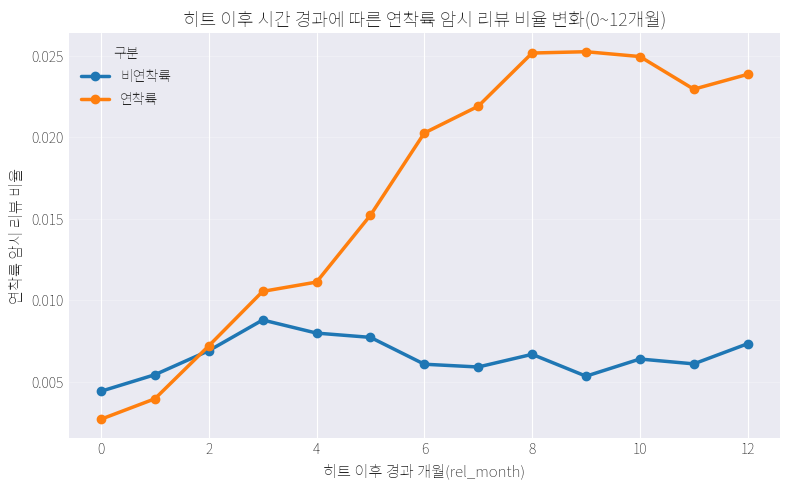

[요약]
연착륙 성공 라벨은 '후반 구간에서도 연착륙 암시 비율이 유지/상승하는지'를 기준으로 생성되며,
위 추세선은 두 그룹의 시간 경과 패턴 차이를 시각적으로 확인하기 위한 그래프이다.


In [17]:
# =============================
# 5) 추세선(선 2개): 연착륙 성공 vs 비연착륙
# =============================
import matplotlib.pyplot as plt

trend_df = (
    df_post
    .groupby(['is_soft_success', 'rel_month'])
    .agg(
        연착륙암시비율=('is_softlanding_review', 'mean'),
        리뷰수=('is_softlanding_review', 'size')
    )
    .reset_index()
)

trend_df['구분'] = trend_df['is_soft_success'].map({0:'비연착륙', 1:'연착륙'})

plt.figure(figsize=(8, 5))
for k, label in [(0, '비연착륙'), (1, '연착륙')]:
    tmp = trend_df[trend_df['is_soft_success'] == k].sort_values('rel_month')
    plt.plot(tmp['rel_month'], tmp['연착륙암시비율'], marker='o', linewidth=2.5, label=label)

plt.title('히트 이후 시간 경과에 따른 연착륙 암시 리뷰 비율 변화(0~12개월)', fontsize=13)
plt.xlabel('히트 이후 경과 개월(rel_month)', fontsize=11)
plt.ylabel('연착륙 암시 리뷰 비율', fontsize=11)
plt.grid(axis='y', alpha=0.25)
plt.legend(title='구분')
plt.tight_layout()
plt.show()

print("[요약]")
print("연착륙 성공 라벨은 '후반 구간에서도 연착륙 암시 비율이 유지/상승하는지'를 기준으로 생성되며,")
print("위 추세선은 두 그룹의 시간 경과 패턴 차이를 시각적으로 확인하기 위한 그래프이다.")

In [18]:
# =============================
# 6) SKU 단위 요약 테이블 만들기: pre/post/delta + 기본 리뷰수
#    - 이후 매출 proxy, 카테고리/브랜드별 비교 등에 바로 사용 가능
# =============================
sku_summary = soft_success_table.copy()

# SKU별 post(0~12) 리뷰수도 붙이기
sku_review_post = (
    df_post.groupby('product_code')
    .size()
    .rename('post리뷰수(0~12)')
    .reset_index()
)

sku_summary = sku_summary.merge(sku_review_post, on='product_code', how='left')
sku_summary['post리뷰수(0~12)'] = sku_summary['post리뷰수(0~12)'].fillna(0).astype(int)

print("[SKU 요약 테이블 샘플]")
display(sku_summary.head())

print("\n[요약]")
print("sku_summary에는 SKU별 연착륙 성공 여부와 초기/후반 평균, 차이(delta), 관측개월수, post 구간 리뷰수가 함께 정리되어 이후 분석(매출 proxy, 특성 비교)에 바로 활용할 수 있다.")

[SKU 요약 테이블 샘플]


,product_code,is_soft_success,초기평균(0~2),후반평균(6~12),차이(후반-초기),관측개월수,post리뷰수(0~12)
0,32262,0,0.0,0.000000,0.000000,11,36
1,49856,1,0.0,0.015873,0.015873,12,46
2,49859,1,0.0,0.020833,0.020833,10,38
3,50371,0,0.0,0.000000,0.000000,13,82
4,55677,1,0.0,0.033395,0.033395,13,121



[요약]
sku_summary에는 SKU별 연착륙 성공 여부와 초기/후반 평균, 차이(delta), 관측개월수, post 구간 리뷰수가 함께 정리되어 이후 분석(매출 proxy, 특성 비교)에 바로 활용할 수 있다.


# 5. 고객 반응 분석: “연착륙 SKU에 달린 리뷰들은 어떤 성향인가?”

## 연착륙 성공 SKU vs 비연착륙 SKU 통계 검정 결과 요약

---

### 1. 평균 평점 차이 (Welch t-test)

**검정 결과**
- t = 7.6440  
- p = 2.113e-14 → 유의 (α=0.05)  
- 효과크기 (Cohen's d) = 0.0282  

**요약**

연착륙 성공 SKU에 속한 리뷰의 평균 평점은 **4.755점**,  
비연착륙 SKU(4.737점) 대비 **0.018점 높게 나타났다** (p=2.113e-14, 유의).

> 통계적으로는 유의하나, 효과크기(d=0.028)는 매우 작은 수준이다.

---

### 2. 감성 속성 차이 (FDR 보정 적용)

연착륙 성공 SKU에서 상대적으로 높게 나타난 상위 속성 (FDR 기준 유의):

- **편의[긍정]**: +0.0541, p(FDR)=5.364e-147 (유의)
- **품질[긍정]**: +0.0245, p(FDR)=1.894e-12 (유의)
- **가성비**: +0.0110, p(FDR)=1.339e-07 (유의)

**해석**

연착륙 성공 SKU는  
특히 *편의성*과 *품질 긍정 언급*이 구조적으로 높은 특징을 보인다.

---

### 3. 감성 차이 상위 속성 재확인

연착륙 성공 SKU에서 특히 차이가 크게 나타난 속성:

- **편의[긍정]**: +0.0541 (유의)
- **품질[긍정]**: +0.0245 (유의)
- **가성비**: +0.0110 (유의)

→ 긍정적 기능 경험 기반 담론이 연착륙 성공과 강하게 연결되어 있음.

---

### 4. 부정 감성 비교

부정 감성 중 연착륙 성공 SKU에서 상대적 증가 항목:

- 물류[부정]: +0.0002, p(FDR)=0.672 → 유의하지 않음
- 심미[부정]: -0.0004, p(FDR)=6.848e-07 → 유의

**해석**

부정 감성은 전반적으로 구조적 차이가 크지 않으며,  
연착륙 성공 여부를 설명하는 핵심 요인은 긍정 기능 담론에 있음.

---

### 5. 연착륙 키워드 등장 카운트 분포 (Mann–Whitney U)

**검정 결과**
- U = 11177916462  
- p = 4.264e-110 → 유의 (α=0.05)

**요약**

연착륙 키워드 매칭 카운트의 평균은 0.012,  
중앙값은 0.000, 상위 75% 지점 역시 0.000.

연착륙 성공 여부에 따른 분포 차이는 통계적으로 유의하였다 (p=4.264e-110).

> 다만 해당 지표는 키워드 등장 횟수 기반이므로  
> 정규화 및 분포 왜도 고려가 필요하다.

---

### 6. 품질_total 차이 (Welch t-test)

품질_total = 품질[긍정] + 품질[부정]

**검정 결과**
- t = 5.2425  
- p = 1.585e-07 → 유의  
- Cohen's d = 0.0194  

**요약**

연착륙 성공 SKU의 품질_total 평균은  
비연착륙 SKU 대비 **0.0196 높게 나타났다** (p=1.585e-07).

→ 연착륙 성공 SKU는 *품질 자체에 대한 담론 강도*가 구조적으로 높다.

---

## ⚠️ 해석 시 주의사항

1. **리뷰 단위 분석이므로 표본 수가 매우 큼**
   - p-value는 매우 작게 나올 가능성이 높음
   - 반드시 효과크기(Cohen's d)와 함께 해석해야 함

2. **효과크기는 전반적으로 매우 작음**
   - 통계적 유의 ≠ 실질적 영향력 큼
   - 구조적 차이 여부 판단에 초점

3. **FDR 보정은 다중검정 오류 통제 목적**
   - 보정 후에도 유의한 항목은 비교적 안정적 차이로 해석 가능

4. **연착륙 키워드 카운트는 분포 왜도가 큼**
   - 평균값보다 분포 형태 확인이 중요
   - 정규성 가정이 어려워 비모수 검정 사용

5. **리뷰 단위 vs SKU 단위 차이**
   - 현재 분석은 리뷰 단위 기준
   - 상품 전략 분석 목적이라면 SKU 단위 재검정이 권장됨

---

## 종합 해석

연착륙 성공 SKU는 단순히 평점이 약간 높은 것이 아니라,  
**편의성·품질 중심의 긍정 담론 구조를 갖는 상품군**으로 나타난다.

다만 효과크기는 작으므로,  
이는 "강한 개별 효과"라기보다는  
**누적된 담론 구조의 차이**로 해석하는 것이 적절하다.

In [19]:
LABEL_MAP = {0: '비연착륙', 1: '연착륙'}

# 그룹별 기본 통계
summary = df.groupby('is_soft_success').agg(
    리뷰수=('text','size'),
    평균평점=('rating','mean'),
    평점표준편차=('rating','std')
)
summary.index = summary.index.map(LABEL_MAP)
summary[['평균평점','평점표준편차']] = summary[['평균평점','평점표준편차']].round(4)

print("[연착륙 성공 여부별 기본 통계]")
display(summary)

# Welch t-test (분산 다를 수 있음)
g0 = df.loc[df['is_soft_success'] == 0, 'rating'].dropna()
g1 = df.loc[df['is_soft_success'] == 1, 'rating'].dropna()

t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False, nan_policy='omit')

# 효과크기 Cohen's d (Welch에 맞춘 pooled SD 근사)
n0, n1 = len(g0), len(g1)
s0, s1 = g0.std(ddof=1), g1.std(ddof=1)
sp = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2)) if (n0+n1-2) > 0 else np.nan
cohen_d = (g1.mean() - g0.mean()) / sp if sp and sp > 0 else np.nan

diff_rating = g1.mean() - g0.mean()
sig = "유의" if p_val < 0.05 else "유의하지 않음"

print("\n[검정 결과: Welch t-test]")
print(f"t = {t_stat:.4f}, p = {p_val:.4g} → {sig} (α=0.05)")
print(f"효과크기(Cohen's d) = {cohen_d:.4f}")

print("\n요약:")
print(f"연착륙 성공 SKU에 속한 리뷰의 평균 평점은 {g1.mean():.3f}점으로 "
      f"비연착륙 SKU({g0.mean():.3f}점) 대비 {diff_rating:.3f}점 높다. "
      f"(p={p_val:.4g}, {sig})")

[연착륙 성공 여부별 기본 통계]


,리뷰수,평균평점,평점표준편차
is_soft_success,,,
비연착륙,202940,4.7372,0.6365
연착륙,109199,4.7549,0.6018



[검정 결과: Welch t-test]
t = 7.6440, p = 2.113e-14 → 유의 (α=0.05)
효과크기(Cohen's d) = 0.0282

요약:
연착륙 성공 SKU에 속한 리뷰의 평균 평점은 4.755점으로 비연착륙 SKU(4.737점) 대비 0.018점 높다. (p=2.113e-14, 유의)


In [20]:
LABEL_MAP = {0: '비연착륙', 1: '연착륙'}

aspect_cols = [
    '가성비','품질[긍정]','품질[부정]','심미[긍정]','심미[부정]',
    '편의[긍정]','편의[부정]','물류[긍정]','물류[부정]',
    '희소성','듀프','로드샵브랜드','브랜드개념','고가브랜드'
]

# 평균표
aspect_mean = df.groupby('is_soft_success')[aspect_cols].mean()
aspect_mean.index = aspect_mean.index.map(LABEL_MAP)

print("[연착륙 성공 여부별 감성 속성 평균]")
display(aspect_mean.T.round(4))

# -----------------------------
# 유의성 검정: Welch t-test (속성별)
# + 다중비교 보정(FDR-BH)
# -----------------------------
g0 = df.loc[df['is_soft_success'] == 0, aspect_cols].fillna(0)
g1 = df.loc[df['is_soft_success'] == 1, aspect_cols].fillna(0)

results = []
for col in aspect_cols:
    x0 = g0[col].to_numpy()
    x1 = g1[col].to_numpy()
    t, p = stats.ttest_ind(x1, x0, equal_var=False, nan_policy='omit')
    diff = np.nanmean(x1) - np.nanmean(x0)
    results.append((col, np.nanmean(x0), np.nanmean(x1), diff, t, p))

res = pd.DataFrame(results, columns=['속성','비연착륙_평균','연착륙_평균','차이(연-비)','t','p'])

# FDR(BH) 보정
res = res.sort_values('p').reset_index(drop=True)
m = len(res)
res['p_FDR'] = (res['p'] * m / (np.arange(m) + 1)).clip(upper=1.0)
# 단조성 보정
res['p_FDR'] = np.minimum.accumulate(res['p_FDR'][::-1])[::-1]
res['유의(FDR<0.05)'] = res['p_FDR'] < 0.05

res[['비연착륙_평균','연착륙_평균','차이(연-비)','t']] = res[['비연착륙_평균','연착륙_평균','차이(연-비)','t']].round(4)
res[['p','p_FDR']] = res[['p','p_FDR']].applymap(lambda v: float(v) if pd.notnull(v) else v)

print("\n[속성별 유의성 검정 결과(Welch t-test, FDR 보정)]")
display(res[['속성','비연착륙_평균','연착륙_평균','차이(연-비)','p','p_FDR','유의(FDR<0.05)']])

# 요약: 차이가 큰 상위 3개(차이 기준) + 유의 여부 표시
mean_table = df.groupby('is_soft_success')[aspect_cols].mean()
diff = (mean_table.loc[1] - mean_table.loc[0]).sort_values(ascending=False)

top3 = diff.head(3)

print("\n요약:")
print("연착륙 성공 SKU에서 상대적으로 높게 나타난 속성(상위 3개)은 다음과 같다(유의성은 FDR 기준).")
for k, v in top3.items():
    p_fdr = res.loc[res['속성'] == k, 'p_FDR'].iloc[0]
    sig = "유의" if p_fdr < 0.05 else "유의하지 않음"
    sign = "+" if v >= 0 else "-"
    print(f"- {k}: {sign}{abs(v):.4f}, p(FDR)={p_fdr:.4g} ({sig})")

[연착륙 성공 여부별 감성 속성 평균]


is_soft_success,비연착륙,연착륙
가성비,0.1726,0.1837
품질[긍정],0.5625,0.5870
품질[부정],0.1217,0.1167
심미[긍정],0.0474,0.0198
심미[부정],0.0006,0.0002
편의[긍정],0.2265,0.2807
편의[부정],0.0115,0.0085
물류[긍정],0.0137,0.0156
물류[부정],0.0147,0.0149
희소성,0.0214,0.0202



[속성별 유의성 검정 결과(Welch t-test, FDR 보정)]


,속성,비연착륙_평균,연착륙_평균,차이(연-비),p,p_FDR,유의(FDR<0.05)
0,심미[긍정],0.0474,0.0198,-0.0276,0.000000e+00,0.000000e+00,True
1,편의[긍정],0.2265,0.2807,0.0541,7.662319e-148,5.363623e-147,True
2,편의[부정],0.0115,0.0085,-0.0030,3.151941e-15,1.470906e-14,True
3,품질[긍정],0.5625,0.5870,0.0245,5.412167e-13,1.894259e-12,True
4,듀프,0.0092,0.0068,-0.0024,2.060395e-12,5.769106e-12,True
5,가성비,0.1726,0.1837,0.0110,5.737036e-08,1.338642e-07,True
6,심미[부정],0.0006,0.0002,-0.0004,3.424147e-07,6.848295e-07,True
7,고가브랜드,0.0006,0.0002,-0.0003,1.891905e-05,3.310834e-05,True
8,물류[긍정],0.0137,0.0156,0.0019,2.694479e-05,4.191412e-05,True
9,품질[부정],0.1217,0.1167,-0.0049,9.059071e-04,1.268270e-03,True



요약:
연착륙 성공 SKU에서 상대적으로 높게 나타난 속성(상위 3개)은 다음과 같다(유의성은 FDR 기준).
- 편의[긍정]: +0.0541, p(FDR)=5.364e-147 (유의)
- 품질[긍정]: +0.0245, p(FDR)=1.894e-12 (유의)
- 가성비: +0.0110, p(FDR)=1.339e-07 (유의)


In [21]:
LABEL_MAP = {0: '비연착륙', 1: '연착륙'}

aspect_cols = [
    '가성비','품질[긍정]','품질[부정]','심미[긍정]','심미[부정]',
    '편의[긍정]','편의[부정]','물류[긍정]','물류[부정]',
    '희소성','듀프','로드샵브랜드','브랜드개념','고가브랜드'
]

mean_table = df.groupby('is_soft_success')[aspect_cols].mean()
diff = (mean_table.loc[1] - mean_table.loc[0]).sort_values(ascending=False)

# p-value 계산 + FDR
g0 = df.loc[df['is_soft_success'] == 0, aspect_cols].fillna(0)
g1 = df.loc[df['is_soft_success'] == 1, aspect_cols].fillna(0)

pvals = {}
for col in aspect_cols:
    t, p = stats.ttest_ind(g1[col], g0[col], equal_var=False, nan_policy='omit')
    pvals[col] = p

p_ser = pd.Series(pvals, name='p').loc[diff.index]

# FDR(BH)
p_sorted = p_ser.sort_values()
m = len(p_sorted)
p_fdr = (p_sorted * m / (np.arange(m) + 1)).clip(upper=1.0)
p_fdr = np.minimum.accumulate(p_fdr[::-1])[::-1]  # 단조성
p_fdr = p_fdr.reindex(p_ser.index)

out = pd.DataFrame({
    '차이(연-비)': diff,
    'p': p_ser,
    'p_FDR': p_fdr,
    '유의(FDR<0.05)': p_fdr < 0.05
}).round({'차이(연-비)':4})

print("[연착륙 성공 - 비연착륙 감성 차이 + 유의성(FDR)]")
display(out)

top3 = out.head(3)

print("\n요약:")
print("연착륙 성공 SKU에서 특히 차이가 크게 나타난 상위 속성은 다음과 같다(FDR 기준 유의 여부 포함).")
for idx, row in top3.iterrows():
    sign = "+" if row['차이(연-비)'] >= 0 else "-"
    sig = "유의" if row['유의(FDR<0.05)'] else "유의하지 않음"
    print(f"- {idx}: {sign}{abs(row['차이(연-비)']):.4f}, p(FDR)={row['p_FDR']:.4g} ({sig})")

[연착륙 성공 - 비연착륙 감성 차이 + 유의성(FDR)]


,차이(연-비),p,p_FDR,유의(FDR<0.05)
편의[긍정],0.0541,7.662319e-148,5.363623e-147,True
품질[긍정],0.0245,5.412167e-13,1.894259e-12,True
가성비,0.0110,5.737036e-08,1.338642e-07,True
물류[긍정],0.0019,2.694479e-05,4.191412e-05,True
물류[부정],0.0002,6.720475e-01,6.720475e-01,False
고가브랜드,-0.0003,1.891905e-05,3.310834e-05,True
심미[부정],-0.0004,3.424147e-07,6.848295e-07,True
브랜드개념,-0.0005,1.052644e-01,1.133616e-01,False
로드샵브랜드,-0.0009,1.673355e-02,2.129724e-02,True
희소성,-0.0012,4.498358e-02,5.248084e-02,False



요약:
연착륙 성공 SKU에서 특히 차이가 크게 나타난 상위 속성은 다음과 같다(FDR 기준 유의 여부 포함).
- 편의[긍정]: +0.0541, p(FDR)=5.364e-147 (유의)
- 품질[긍정]: +0.0245, p(FDR)=1.894e-12 (유의)
- 가성비: +0.0110, p(FDR)=1.339e-07 (유의)


In [22]:
LABEL_MAP = {0: '비연착륙', 1: '연착륙'}

negative_cols = ['품질[부정]','심미[부정]','편의[부정]','물류[부정]']

negative_mean = df.groupby('is_soft_success')[negative_cols].mean()
negative_mean.index = negative_mean.index.map(LABEL_MAP)

print("[연착륙 성공 여부별 부정 감성 평균]")
display(negative_mean.round(4))

# 유의성 검정(Welch) + FDR
g0 = df.loc[df['is_soft_success'] == 0, negative_cols].fillna(0)
g1 = df.loc[df['is_soft_success'] == 1, negative_cols].fillna(0)

rows = []
for col in negative_cols:
    t, p = stats.ttest_ind(g1[col], g0[col], equal_var=False, nan_policy='omit')
    diff = g1[col].mean() - g0[col].mean()
    rows.append((col, g0[col].mean(), g1[col].mean(), diff, p))

res = pd.DataFrame(rows, columns=['속성','비연착륙_평균','연착륙_평균','차이(연-비)','p']).sort_values('p').reset_index(drop=True)
m = len(res)
res['p_FDR'] = (res['p'] * m / (np.arange(m) + 1)).clip(upper=1.0)
res['p_FDR'] = np.minimum.accumulate(res['p_FDR'][::-1])[::-1]
res['유의(FDR<0.05)'] = res['p_FDR'] < 0.05
res[['비연착륙_평균','연착륙_평균','차이(연-비)']] = res[['비연착륙_평균','연착륙_평균','차이(연-비)']].round(4)

print("\n[부정 감성 속성별 유의성(Welch t-test, FDR)]")
display(res[['속성','비연착륙_평균','연착륙_평균','차이(연-비)','p','p_FDR','유의(FDR<0.05)']])

# 요약: 차이가 큰 상위 2개(차이 기준) + 유의성 표시
neg_diff = (negative_mean.loc['연착륙'] - negative_mean.loc['비연착륙']).sort_values(ascending=False)
top2 = neg_diff.head(2)

print("\n요약:")
print("부정 감성 중 연착륙 성공 SKU에서 상대적으로 증가한 항목(상위 2개)은 다음과 같다(FDR 기준).")
for k, v in top2.items():
    p_fdr = res.loc[res['속성'] == k, 'p_FDR'].iloc[0]
    sig = "유의" if p_fdr < 0.05 else "유의하지 않음"
    sign = "+" if v >= 0 else "-"
    print(f"- {k}: {sign}{abs(v):.4f}, p(FDR)={p_fdr:.4g} ({sig})")

[연착륙 성공 여부별 부정 감성 평균]


,품질[부정],심미[부정],편의[부정],물류[부정]
is_soft_success,,,,
비연착륙,0.1217,0.0006,0.0115,0.0147
연착륙,0.1167,0.0002,0.0085,0.0149



[부정 감성 속성별 유의성(Welch t-test, FDR)]


,속성,비연착륙_평균,연착륙_평균,차이(연-비),p,p_FDR,유의(FDR<0.05)
0,편의[부정],0.0115,0.0085,-0.0030,3.151941e-15,1.260776e-14,True
1,심미[부정],0.0006,0.0002,-0.0004,3.424147e-07,6.848295e-07,True
2,품질[부정],0.1217,0.1167,-0.0049,9.059071e-04,1.207876e-03,True
3,물류[부정],0.0147,0.0149,0.0002,6.720475e-01,6.720475e-01,False



요약:
부정 감성 중 연착륙 성공 SKU에서 상대적으로 증가한 항목(상위 2개)은 다음과 같다(FDR 기준).
- 물류[부정]: +0.0002, p(FDR)=0.672 (유의하지 않음)
- 심미[부정]: -0.0004, p(FDR)=6.848e-07 (유의)


In [23]:
desc = df['연착륙'].describe()

print("[연착륙(키워드 매칭 카운트) 분포 요약]")
display(desc.round(3))

# 그룹 간 비교: Mann–Whitney U (비정규/카운트에 강함)
g0 = df.loc[df['is_soft_success'] == 0, '연착륙'].fillna(0)
g1 = df.loc[df['is_soft_success'] == 1, '연착륙'].fillna(0)

u_stat, p_val = stats.mannwhitneyu(g1, g0, alternative='two-sided')
sig = "유의" if p_val < 0.05 else "유의하지 않음"

print("\n[검정 결과: Mann–Whitney U]")
print(f"U = {u_stat:.0f}, p = {p_val:.4g} → {sig} (α=0.05)")

print("\n요약:")
print(f"연착륙(키워드 매칭 카운트)의 평균은 {desc['mean']:.3f}, 중앙값은 {desc['50%']:.3f}이며, "
      f"상위 75% 지점은 {desc['75%']:.3f}로 나타났다.")
print(f"연착륙 성공 여부에 따른 '연착륙 카운트' 분포 차이는 {sig}로 나타났다(p={p_val:.4g}).")
print("해당 값은 키워드 등장 횟수 기반이므로, 점수형 지표로 해석할 때는 전처리/정규화 여부를 함께 고려하는 것이 안전하다.")

[연착륙(키워드 매칭 카운트) 분포 요약]


count    312139.000
mean          0.012
std           0.111
min           0.000
25%           0.000
50%           0.000
75%           0.000
max           3.000
Name: 연착륙, dtype: float64


[검정 결과: Mann–Whitney U]
U = 11177916462, p = 4.264e-110 → 유의 (α=0.05)

요약:
연착륙(키워드 매칭 카운트)의 평균은 0.012, 중앙값은 0.000이며, 상위 75% 지점은 0.000로 나타났다.
연착륙 성공 여부에 따른 '연착륙 카운트' 분포 차이는 유의로 나타났다(p=4.264e-110).
해당 값은 키워드 등장 횟수 기반이므로, 점수형 지표로 해석할 때는 전처리/정규화 여부를 함께 고려하는 것이 안전하다.


In [24]:
LABEL_MAP = {0: '비연착륙', 1: '연착륙'}

df['품질_total'] = df['품질[긍정]'] + df['품질[부정]']

quality_total_mean = (
    df.groupby('is_soft_success')['품질_total']
      .agg(['mean','std','count'])
      .rename(columns={'mean':'품질_total_평균','std':'표준편차','count':'리뷰수'})
      .rename(index=LABEL_MAP)
)

quality_total_mean['품질_total_평균'] = quality_total_mean['품질_total_평균'].round(4)
quality_total_mean['표준편차'] = quality_total_mean['표준편차'].round(4)

print("[연착륙 성공 여부별 품질_total 통계]")
display(quality_total_mean)

g0 = df.loc[df['is_soft_success'] == 0, '품질_total'].fillna(0)
g1 = df.loc[df['is_soft_success'] == 1, '품질_total'].fillna(0)

t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False, nan_policy='omit')

# Cohen's d
n0, n1 = len(g0), len(g1)
s0, s1 = g0.std(ddof=1), g1.std(ddof=1)
sp = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2)) if (n0+n1-2) > 0 else np.nan
cohen_d = (g1.mean() - g0.mean()) / sp if sp and sp > 0 else np.nan

gap = g1.mean() - g0.mean()
direction = "높다" if gap > 0 else "낮다" if gap < 0 else "동일하다"
sig = "유의" if p_val < 0.05 else "유의하지 않음"

print("\n[검정 결과: Welch t-test]")
print(f"t = {t_stat:.4f}, p = {p_val:.4g} → {sig} (α=0.05)")
print(f"효과크기(Cohen's d) = {cohen_d:.4f}")

print("\n요약:")
print(f"연착륙 성공 SKU의 품질_total 평균은 비연착륙 SKU 대비 {abs(gap):.4f} 만큼 {direction} "
      f"(p={p_val:.4g}, {sig}).")
print("품질_total은 '품질[긍정]+품질[부정]'이므로, 연착륙 성공 SKU에서 '품질' 중심의 언급 강도가 더 큰지 확인하는 지표로 해석할 수 있다.")

[연착륙 성공 여부별 품질_total 통계]


,품질_total_평균,표준편차,리뷰수
is_soft_success,,,
비연착륙,0.6841,1.0219,202940
연착륙,0.7037,0.9799,109199



[검정 결과: Welch t-test]
t = 5.2425, p = 1.585e-07 → 유의 (α=0.05)
효과크기(Cohen's d) = 0.0194

요약:
연착륙 성공 SKU의 품질_total 평균은 비연착륙 SKU 대비 0.0196 만큼 높다 (p=1.585e-07, 유의).
품질_total은 '품질[긍정]+품질[부정]'이므로, 연착륙 성공 SKU에서 '품질' 중심의 언급 강도가 더 큰지 확인하는 지표로 해석할 수 있다.


# 6. 연착륙 성공 상품들의 매출은 어느정도? 

In [25]:

# =========================================
# 0) 준비: 리뷰수(실제) 집계 + 상품정보 결합 + 추정매출 산출
#    - 라벨은 is_soft_success(SKU 단위 연착륙 성공) 기준으로 붙인다
# =========================================

# 0-1) SKU별 실제 리뷰수(리뷰 테이블 기준)
review_cnt = (
    df_reviews
    .groupby('product_code')
    .size()
    .reset_index(name='리뷰수_실제')
)

# 0-2) 상품 테이블 복사
df_product = df_products.copy()

# 0-3) 상품 + 리뷰수 merge
df_sales = df_product.merge(
    review_cnt,
    on='product_code',
    how='left'
)

df_sales['리뷰수_실제'] = df_sales['리뷰수_실제'].fillna(0).astype(int)

# 0-4) price 숫자 보정(문자열/쉼표 대비)
df_sales['price'] = pd.to_numeric(df_sales['price'], errors='coerce')
df_sales['price'] = df_sales['price'].fillna(0)

# 0-5) 추정매출 = 가격 * 리뷰수
df_sales['추정매출'] = df_sales['price'] * df_sales['리뷰수_실제']

# 0-6) SKU 단위 연착륙 성공 라벨 붙이기
# soft_success_table 또는 df의 SKU 라벨을 사용
# (이미 soft_success_table이 있다면 그걸 쓰는 게 가장 깔끔)
if 'soft_success_table' in globals():
    sku_soft = soft_success_table[['product_code', 'is_soft_success']].copy()
else:
    # df에 이미 is_soft_success가 붙어있는 경우
    sku_soft = (
        df.groupby('product_code')['is_soft_success']
        .max()
        .reset_index()
    )

df_sales = df_sales.merge(
    sku_soft,
    on='product_code',
    how='left'
)

df_sales['is_soft_success'] = df_sales['is_soft_success'].fillna(0).astype(int)

LABEL_MAP = {0: '비연착륙', 1: '연착륙'}
total_sales = df_sales['추정매출'].sum()

print("[df_sales 생성 완료]")
print("상품 수:", len(df_sales))
print("추정매출 합계:", f"{total_sales:,.0f}")
print("\n[요약]")
print("df_sales는 '상품 정보 + 실제 리뷰수 + 추정매출(가격×리뷰수) + SKU 단위 연착륙 성공 라벨(is_soft_success)'을 결합한 분석용 테이블이다.")

[df_sales 생성 완료]
상품 수: 954
추정매출 합계: 1,175,035,500

[요약]
df_sales는 '상품 정보 + 실제 리뷰수 + 추정매출(가격×리뷰수) + SKU 단위 연착륙 성공 라벨(is_soft_success)'을 결합한 분석용 테이블이다.


In [26]:
# =========================================
# 1) 연착륙 성공 여부별 추정매출 합계 & 비중
# =========================================
sales_summary = (
    df_sales
    .groupby('is_soft_success')['추정매출']
    .sum()
    .rename(index=LABEL_MAP)
)

sales_ratio = (sales_summary / sales_summary.sum()).rename('추정매출_비중')

sales_table = (
    pd.concat([sales_summary.rename('추정매출_합계'), sales_ratio], axis=1)
    .reset_index()
    .rename(columns={'is_soft_success': '연착륙_여부'})
)

sales_table['추정매출_합계'] = sales_table['추정매출_합계'].round(0).astype('int64')
sales_table['추정매출_비중'] = (sales_table['추정매출_비중'] * 100).round(2)

print("[연착륙 성공 여부별 추정매출(가격×리뷰수) 합계 및 비중]")
display(sales_table)

soft_sales = sales_summary.get('연착륙', 0)
nonsoft_sales = sales_summary.get('비연착륙', 0)
soft_share = (soft_sales / (soft_sales + nonsoft_sales) * 100) if (soft_sales + nonsoft_sales) > 0 else 0

print("\n[요약]")
print(f"연착륙 성공 SKU의 추정매출은 {soft_sales:,.0f}로 전체의 {soft_share:.2f}%를 차지했다."
      f" (비연착륙: {nonsoft_sales:,.0f}, {100-soft_share:.2f}%)")

[연착륙 성공 여부별 추정매출(가격×리뷰수) 합계 및 비중]


,연착륙_여부,추정매출_합계,추정매출_비중
0,비연착륙,701877500,59.73
1,연착륙,473158000,40.27



[요약]
연착륙 성공 SKU의 추정매출은 473,158,000로 전체의 40.27%를 차지했다. (비연착륙: 701,877,500, 59.73%)


In [27]:
# =========================================
# 2) SKU 비중(상품 수 비중)
# =========================================
sku_ratio = (
    df_sales['is_soft_success']
    .value_counts(normalize=True)
    .rename(index=LABEL_MAP)
    .rename('SKU_비중')
)

sku_table = (
    sku_ratio.mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'index': '연착륙_여부'})
)

print("[연착륙 성공 여부별 SKU 비중]")
display(sku_table)

soft_sku_share = sku_ratio.get('연착륙', 0) * 100
nonsoft_sku_share = sku_ratio.get('비연착륙', 0) * 100
sku_n = len(df_sales)
soft_n = int((df_sales['is_soft_success'] == 1).sum())
nonsoft_n = int((df_sales['is_soft_success'] == 0).sum())

print("\n[요약]")
print(f"전체 {sku_n:,}개 상품 중 연착륙 성공 SKU는 {soft_n:,}개({soft_sku_share:.2f}%), "
      f"비연착륙 SKU는 {nonsoft_n:,}개({nonsoft_sku_share:.2f}%)였다.")

[연착륙 성공 여부별 SKU 비중]


,is_soft_success,SKU_비중
0,비연착륙,81.03
1,연착륙,18.97



[요약]
전체 954개 상품 중 연착륙 성공 SKU는 181개(18.97%), 비연착륙 SKU는 773개(81.03%)였다.


In [28]:
# =========================================
# 3) 상위 10개 SKU 매출 집중도
# =========================================
top10_sales = (
    df_sales
    .sort_values('추정매출', ascending=False)
    .head(10)['추정매출']
    .sum()
)

top10_ratio = (top10_sales / total_sales) if total_sales > 0 else 0

top10_table = pd.DataFrame({
    '지표': ['상위 10개 SKU 추정매출', '전체 SKU 추정매출', '상위 10개 SKU 매출 비중(%)'],
    '값': [top10_sales, total_sales, top10_ratio * 100]
})

top10_table.loc[top10_table['지표'] != '상위 10개 SKU 매출 비중(%)', '값'] = (
    top10_table.loc[top10_table['지표'] != '상위 10개 SKU 매출 비중(%)', '값']
    .round(0).astype('int64')
)
top10_table.loc[top10_table['지표'] == '상위 10개 SKU 매출 비중(%)', '값'] = (
    top10_table.loc[top10_table['지표'] == '상위 10개 SKU 매출 비중(%)', '값']
    .round(2)
)

print("[상위 10개 SKU 매출 집중도]")
display(top10_table)

print("\n[요약]")
print(f"상위 10개 SKU의 추정매출은 {top10_sales:,.0f}로, 전체 추정매출의 {top10_ratio*100:.2f}%를 차지했다.")
print("이는 소수 SKU에 매출이 집중되는지(파레토 구조)를 판단하는 핵심 지표로 활용할 수 있다.")

[상위 10개 SKU 매출 집중도]


,지표,값
0,상위 10개 SKU 추정매출,2.222120e+08
1,전체 SKU 추정매출,1.175036e+09
2,상위 10개 SKU 매출 비중(%),1.891000e+01



[요약]
상위 10개 SKU의 추정매출은 222,212,000로, 전체 추정매출의 18.91%를 차지했다.
이는 소수 SKU에 매출이 집중되는지(파레토 구조)를 판단하는 핵심 지표로 활용할 수 있다.


In [29]:
# =========================================
# 4) 연착륙 성공 SKU가 상위 매출 SKU에 얼마나 포함되는지
#    - 발표에서 '효자상품=연착륙 성공' 연결할 때 유용할듯!
# =========================================
topN = 50

topN_df = df_sales.sort_values('추정매출', ascending=False).head(topN).copy()
topN_df['연착륙_여부'] = topN_df['is_soft_success'].map(LABEL_MAP)

cnt_topN = topN_df['연착륙_여부'].value_counts()
ratio_topN = topN_df['연착륙_여부'].value_counts(normalize=True)

summary_topN = pd.DataFrame({
    f'상위{topN}개 SKU 수': cnt_topN,
    f'상위{topN}개 내 비중': ratio_topN.round(4)
})

print(f"[상위 {topN}개 SKU 내 연착륙 성공 분포]")
display(summary_topN)

soft_in_topN = int((topN_df['is_soft_success'] == 1).sum())
print("\n[요약]")
print(f"상위 {topN}개 SKU 중 연착륙 성공 SKU는 {soft_in_topN}개로, 상위 매출 SKU 집단 내에서 연착륙 성공 상품이 차지하는 비중을 확인할 수 있다.")

[상위 50개 SKU 내 연착륙 성공 분포]


,상위50개 SKU 수,상위50개 내 비중
연착륙_여부,,
비연착륙,27,0.54
연착륙,23,0.46



[요약]
상위 50개 SKU 중 연착륙 성공 SKU는 23개로, 상위 매출 SKU 집단 내에서 연착륙 성공 상품이 차지하는 비중을 확인할 수 있다.


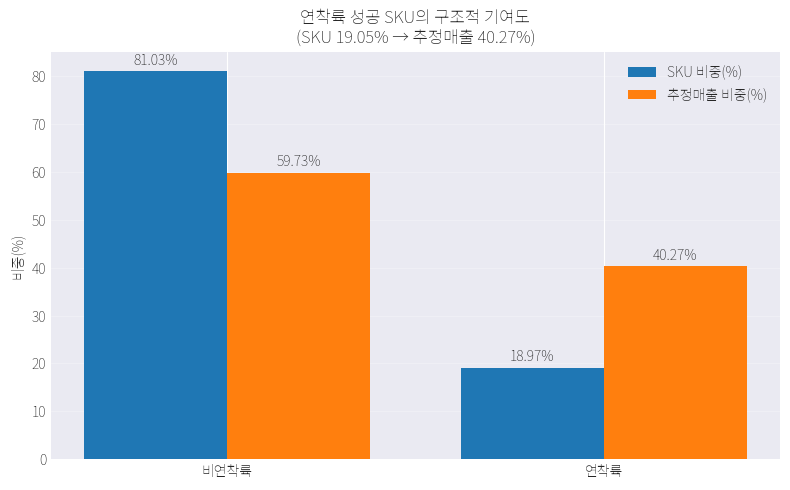

[요약]
연착륙 성공 SKU는 전체 950개 중 181개(19.05%)이며, 추정매출 기준 40.27%를 기여한다.


In [30]:
# -----------------------------
# 공통 준비
# -----------------------------
LABEL_MAP = {0: '비연착륙', 1: '연착륙'}
df_plot = df_sales.copy()

df_plot['is_soft_success'] = df_plot['is_soft_success'].fillna(0).astype(int)
df_plot['연착륙_여부'] = df_plot['is_soft_success'].map(LABEL_MAP)

# 숫자
n_total = df_plot['product_code'].nunique()
n_soft = int((df_plot['is_soft_success'] == 1).sum())
n_nonsoft = int((df_plot['is_soft_success'] == 0).sum())
total_sales = df_plot['추정매출'].sum()
soft_sales = df_plot.loc[df_plot['is_soft_success'] == 1, '추정매출'].sum()
nonsoft_sales = df_plot.loc[df_plot['is_soft_success'] == 0, '추정매출'].sum()

soft_sku_share = n_soft / n_total * 100 if n_total else 0
soft_sales_share = soft_sales / total_sales * 100 if total_sales else 0

def won_formatter_100m(x, pos):
    # 1억=1e8. 기존 너 코드가 1e7로 '억' 표기였는데, 여기서는 정확히 1e8 기준.
    return f'{x/1e8:.1f}억'

# -----------------------------
# 그래프 1) SKU 비중 vs 매출 비중 (핵심 메시지)
# -----------------------------
sku_share = (
    df_plot['is_soft_success'].value_counts(normalize=True)
    .sort_index()
    .rename(index=LABEL_MAP)
    * 100
)

sales_share = (
    df_plot.groupby('is_soft_success')['추정매출'].sum()
    .sort_index()
    .rename(index=LABEL_MAP)
)
sales_share = (sales_share / sales_share.sum() * 100)

comp = pd.DataFrame({
    'SKU 비중(%)': sku_share,
    '추정매출 비중(%)': sales_share
})

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comp.index))
width = 0.38

ax.bar(x - width/2, comp['SKU 비중(%)'], width, label='SKU 비중(%)')
ax.bar(x + width/2, comp['추정매출 비중(%)'], width, label='추정매출 비중(%)')

ax.set_xticks(x)
ax.set_xticklabels(comp.index)
ax.set_ylabel('비중(%)')
ax.set_title(f"연착륙 성공 SKU의 구조적 기여도\n(SKU {soft_sku_share:.2f}% → 추정매출 {soft_sales_share:.2f}%)")
ax.grid(axis='y', alpha=0.25)
ax.legend()

# 막대 위 수치
for i, k in enumerate(comp.index):
    ax.text(i - width/2, comp.loc[k, 'SKU 비중(%)'] + 0.6, f"{comp.loc[k, 'SKU 비중(%)']:.2f}%", ha='center', va='bottom', fontsize=10)
    ax.text(i + width/2, comp.loc[k, '추정매출 비중(%)'] + 0.6, f"{comp.loc[k, '추정매출 비중(%)']:.2f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("[요약]")
print(f"연착륙 성공 SKU는 전체 {n_total:,}개 중 {n_soft:,}개({soft_sku_share:.2f}%)이며, "
      f"추정매출 기준 {soft_sales_share:.2f}%를 기여한다.")

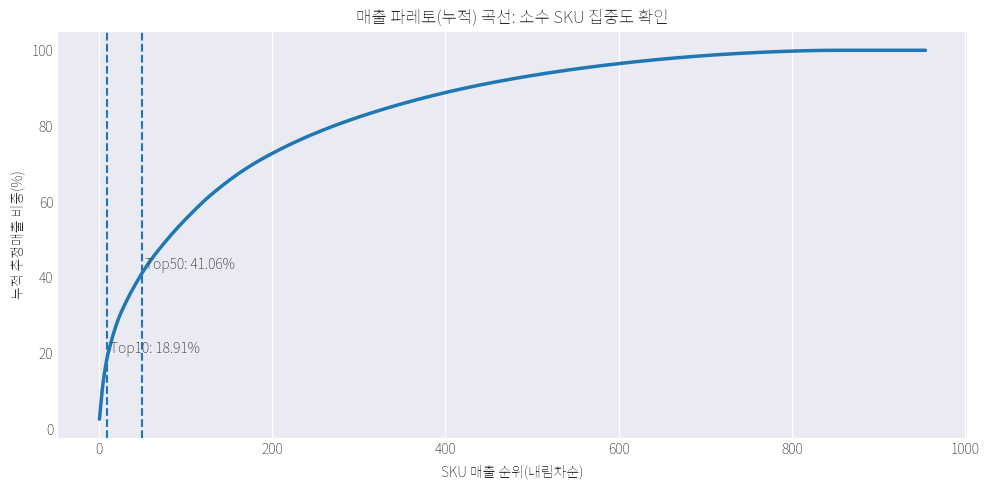

[요약]
상위 10개 SKU는 전체 추정매출의 18.91% 수준을 차지한다.
상위 50개 SKU 누적 비중은 41.06%로, 매출이 소수 SKU에 집중되는 구조를 확인할 수 있다.


In [31]:
# -----------------------------
# 그래프 2) 파레토(누적 매출) + Top10/Top50 지점 표시
# -----------------------------
df_rank = df_plot[['product_code', '추정매출', '연착륙_여부']].copy()
df_rank = df_rank.sort_values('추정매출', ascending=False).reset_index(drop=True)
df_rank['순위'] = np.arange(1, len(df_rank) + 1)
df_rank['누적매출'] = df_rank['추정매출'].cumsum()
df_rank['누적매출비중(%)'] = df_rank['누적매출'] / df_rank['추정매출'].sum() * 100

top10_share = df_rank.loc[df_rank['순위'] == 10, '누적매출비중(%)'].iloc[0] if len(df_rank) >= 10 else np.nan
top50_share = df_rank.loc[df_rank['순위'] == 50, '누적매출비중(%)'].iloc[0] if len(df_rank) >= 50 else np.nan

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_rank['순위'], df_rank['누적매출비중(%)'], linewidth=2.5)
ax.set_xlabel('SKU 매출 순위(내림차순)')
ax.set_ylabel('누적 추정매출 비중(%)')
ax.set_title('매출 파레토(누적) 곡선: 소수 SKU 집중도 확인')
ax.grid(axis='y', alpha=0.25)

# Top10, Top50 표시
if len(df_rank) >= 10:
    ax.axvline(10, linestyle='--', linewidth=1.5)
    ax.text(10, top10_share, f" Top10: {top10_share:.2f}%", va='bottom', fontsize=10)
if len(df_rank) >= 50:
    ax.axvline(50, linestyle='--', linewidth=1.5)
    ax.text(50, top50_share, f" Top50: {top50_share:.2f}%", va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("[요약]")
print(f"상위 10개 SKU는 전체 추정매출의 {top10_share:.2f}% 수준을 차지한다.")
if len(df_rank) >= 50:
    print(f"상위 50개 SKU 누적 비중은 {top50_share:.2f}%로, 매출이 소수 SKU에 집중되는 구조를 확인할 수 있다.")

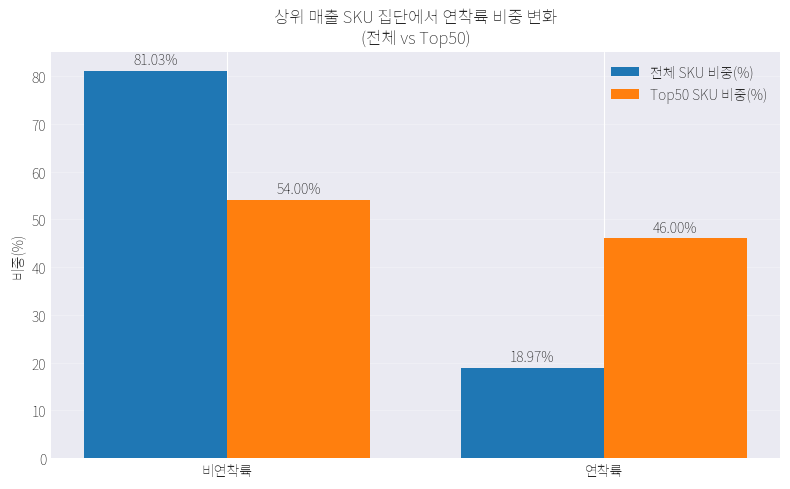

[요약]
전체 SKU에서 연착륙 비중은 18.97%이며, Top50 SKU에서는 46.00%로 상승했다.
즉, 매출 상위 집단으로 갈수록 연착륙 성공 SKU의 비중이 커지는 경향을 확인할 수 있다.


In [32]:
# -----------------------------
# 그래프 3) Top50 구성: 연착륙 비중이 상위 매출군에서 상승하는지
# -----------------------------
topN = 50
topN_df = df_rank.head(topN).copy()

topN_counts = topN_df['연착륙_여부'].value_counts().reindex(['비연착륙', '연착륙']).fillna(0).astype(int)
topN_ratio = (topN_counts / topN_counts.sum() * 100).round(2)

overall_counts = df_plot['연착륙_여부'].value_counts().reindex(['비연착륙', '연착륙']).fillna(0).astype(int)
overall_ratio = (overall_counts / overall_counts.sum() * 100).round(2)

compare_ratio = pd.DataFrame({
    '전체 SKU 비중(%)': overall_ratio,
    f'Top{topN} SKU 비중(%)': topN_ratio
})

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(compare_ratio.index))
width = 0.38

ax.bar(x - width/2, compare_ratio['전체 SKU 비중(%)'], width, label='전체 SKU 비중(%)')
ax.bar(x + width/2, compare_ratio[f'Top{topN} SKU 비중(%)'], width, label=f'Top{topN} SKU 비중(%)')

ax.set_xticks(x)
ax.set_xticklabels(compare_ratio.index)
ax.set_ylabel('비중(%)')
ax.set_title(f"상위 매출 SKU 집단에서 연착륙 비중 변화\n(전체 vs Top{topN})")
ax.grid(axis='y', alpha=0.25)
ax.legend()

for i, k in enumerate(compare_ratio.index):
    ax.text(i - width/2, compare_ratio.loc[k, '전체 SKU 비중(%)'] + 0.6, f"{compare_ratio.loc[k, '전체 SKU 비중(%)']:.2f}%", ha='center', va='bottom', fontsize=10)
    ax.text(i + width/2, compare_ratio.loc[k, f'Top{topN} SKU 비중(%)'] + 0.6, f"{compare_ratio.loc[k, f'Top{topN} SKU 비중(%)']:.2f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("[요약]")
print(f"전체 SKU에서 연착륙 비중은 {overall_ratio['연착륙']:.2f}%이며, Top{topN} SKU에서는 {topN_ratio['연착륙']:.2f}%로 상승했다.")
print("즉, 매출 상위 집단으로 갈수록 연착륙 성공 SKU의 비중이 커지는 경향을 확인할 수 있다.")

### 효자 SKU 1개당 평균 매출 비교 (몇 배인가)

In [33]:
# -----------------------------
# 1) SKU 단위 평균 추정매출 계산
# -----------------------------
sku_avg_sales = (
    df_sales
    .groupby('is_soft_success')['추정매출']
    .agg(['mean', 'count', 'sum'])
    .rename(columns={
        'mean': 'SKU당_평균추정매출',
        'count': 'SKU수',
        'sum': '총추정매출'
    })
)

sku_avg_sales.index = sku_avg_sales.index.map({0: '비연착륙', 1: '연착륙'})

# 반올림
sku_avg_sales['SKU당_평균추정매출'] = sku_avg_sales['SKU당_평균추정매출'].round(0).astype('int64')
sku_avg_sales['총추정매출'] = sku_avg_sales['총추정매출'].round(0).astype('int64')

print("[연착륙 여부별 SKU당 평균 추정매출]")
display(sku_avg_sales)

# -----------------------------
# 2) 몇 배 차이인가
# -----------------------------
avg_soft = sku_avg_sales.loc['연착륙', 'SKU당_평균추정매출']
avg_nonsoft = sku_avg_sales.loc['비연착륙', 'SKU당_평균추정매출']

multiple = avg_soft / avg_nonsoft if avg_nonsoft > 0 else np.nan

print("\n[요약]")
print(f"연착륙 SKU 1개당 평균 추정매출은 {avg_soft:,.0f}원이며, "
      f"비연착륙 SKU({avg_nonsoft:,.0f}원) 대비 약 {multiple:.2f}배 수준이다.")
print("즉, 효자상품 1개는 일반 상품 여러 개에 해당하는 매출 기여도를 가진다.")

[연착륙 여부별 SKU당 평균 추정매출]


,SKU당_평균추정매출,SKU수,총추정매출
is_soft_success,,,
비연착륙,907992,773,701877500
연착륙,2614133,181,473158000



[요약]
연착륙 SKU 1개당 평균 추정매출은 2,614,133원이며, 비연착륙 SKU(907,992원) 대비 약 2.88배 수준이다.
즉, 효자상품 1개는 일반 상품 여러 개에 해당하는 매출 기여도를 가진다.


In [34]:
# -----------------------------
# 2024년 다이소 전체 매출
# -----------------------------
total_revenue_2024 = 3_4604 * 1e8  # 3조 4604억 원 → 원 단위
# 설명: 1억 = 1e8

# 화장품 비중 10% 가정
cosmetics_ratio = 0.10

cosmetics_revenue_est = total_revenue_2024 * cosmetics_ratio

print("[2024년 다이소 화장품 매출 추정]")
print(f"전체 매출: {total_revenue_2024:,.0f}원")
print(f"화장품 매출(10% 가정): {cosmetics_revenue_est:,.0f}원")

# -----------------------------
# 연착륙 매출 비중 적용
# -----------------------------
soft_sales_ratio = soft_sales / total_sales if total_sales > 0 else 0

cosmetics_soft_est = cosmetics_revenue_est * soft_sales_ratio

print("\n[연착륙 SKU 매출 추정 규모]")
print(f"연착륙 SKU 비중({soft_sales_ratio*100:.2f}%) 적용 시")
print(f"연착륙 SKU 매출 규모 추정: {cosmetics_soft_est:,.0f}원")

[2024년 다이소 화장품 매출 추정]
전체 매출: 3,460,400,000,000원
화장품 매출(10% 가정): 346,040,000,000원

[연착륙 SKU 매출 추정 규모]
연착륙 SKU 비중(40.27%) 적용 시
연착륙 SKU 매출 규모 추정: 139,341,827,817원


# 상품 전략 분석: 연착륙 SKU 자체는 어떤 특성을 가지는가?

## SKU 단위 분석 결과 요약

### 1. 분석 개요

- 분석 단위: SKU(상품) 단위
- 전체 SKU 수: 954개
- 연착륙 성공 여부(is_soft_success) 기준 비교

---

### 2. 대분류(category_1) 분포 차이

#### 교차표

| 대분류 | 비연착륙 | 연착륙 |
|--------|----------|--------|
| 맨케어 | 63 | 10 |
| 메이크업 | 380 | 66 |
| 스킨케어 | 330 | 105 |

#### 카이제곱 검정 결과

- chi2 = 13.9259  
- p = 9.4632e-04  
- 유의 (α = 0.05)

#### 해석

대분류에 따라 연착륙 성공 여부 분포는 통계적으로 유의하게 다르다.  
특히 스킨케어 카테고리에서 연착륙 성공 비율이 상대적으로 높게 나타났다.

---

### 3. 중분류(category_2) 분포 차이

#### 카이제곱 검정 결과

- chi2 = 77.3414  
- p = 3.4795e-11  
- 유의 (α = 0.05)

중분류 수준에서는 연착륙 성공 여부의 분포 차이가 더욱 뚜렷하게 나타났다.

#### 중분류별 연착륙 비율 (100% 기준)

| 중분류 | 연착륙 비율 |
|--------|------------|
| 기초스킨케어 | 36.16% |
| 자외선차단제 | 25.58% |
| 립메이크업 | 17.42% |
| 아이메이크업 | 17.19% |
| 베이스메이크업 | 14.29% |
| 립케어 | 13.33% |
| 팩/마스크 | 8.82% |
| 치크/하이라이터 | 7.41% |
| 클렌징/필링 | 5.77% |
| 남성용면도기 | 3.33% |

#### 해석

기초스킨케어가 가장 높은 연착륙 비율을 보였다.  
기능 중심, 루틴형 제품군이 스테디셀러 구조에 유리할 가능성이 높다.  
반면 색조 및 트렌드 중심 제품군은 상대적으로 연착륙 비율이 낮다.

---

### 4. SKU 평균 평점 차이

#### Welch t-test 결과

- t = 4.0836  
- p = 5.2884e-05  
- 유의 (α = 0.05)

| 구분 | 평균 평점 |
|------|-----------|
| 연착륙 | 4.716 |
| 비연착륙 | 4.676 |

#### 해석

연착륙 SKU는 평균적으로 더 높은 평점을 보이며, 그 차이는 통계적으로 유의하다.
다만 이는 표본의 방대함(약 30만 건)으로 인해 나타나는 유의성으로 보인다. 
(표본이 크면 클수록 절대적으로는 작은 차이라도 통계적으로 유의한 결과가 나올 수 있음)

---

### 5. SKU 단위 감성 평균 차이 (FDR 보정 기준)

#### 유의한 변수

| 변수 | 차이(연-비) | p(FDR) | 방향 |
|------|------------|--------|------|
| 편의[긍정] | +0.0389 | 0.0010 | 증가 |
| 품질[긍정] | +0.0349 | 0.0014 | 증가 |
| 편의[부정] | -0.0035 | 0.0388 | 감소 |
| 심미[긍정] | -0.0365 | 0.0000 | 감소 |

#### 해석

연착륙 성공 SKU는 편의성과 품질에 대한 긍정 언급이 높다.  
반면 심미적 요소(디자인 중심 언급)는 상대적으로 낮은 경향을 보인다.  

즉, 디자인 중심 제품보다는  
사용 편의성과 품질 기반 제품이 연착륙 구조와 더 밀접하다.

---

### 6. SKU 단위 연착륙 성공 예측 모델 (로지스틱 회귀)

#### 연착륙 확률을 높이는 주요 변수 (오즈비 기준)

| 변수 | 오즈비 |
|------|--------|
| 가성비 | 6.7381 |
| 편의[긍정] | 4.5387 |
| 품질[긍정] | 3.8449 |
| 로드샵브랜드 | 1.5142 |

#### 연착륙 확률을 낮추는 주요 변수

| 변수 | 오즈비 |
|------|--------|
| 심미[긍정] | 0.3452 |
| 편의[부정] | 0.6796 |
| 물류[긍정] | 0.6877 |

#### 종합 해석

연착륙 성공을 가장 강하게 설명하는 요인은 다음과 같다.

1. 가성비
2. 편의성 긍정 언급
3. 품질 긍정 언급

즉, 다이소 뷰티의 연착륙 구조는  
가성비 × 품질 × 사용 편의성의 결합 구조로 해석할 수 있다.

In [35]:
# ---------------------------------
# 1) 리뷰 기반 감성/평점 SKU 집계
# ---------------------------------
aspect_cols = [
    '가성비',
    '품질[긍정]',
    '품질[부정]',
    '심미[긍정]',
    '심미[부정]',
    '편의[긍정]',
    '편의[부정]',
    '물류[긍정]',
    '물류[부정]',
    '희소성',
    '듀프',
    '로드샵브랜드',
    '브랜드개념',
    '고가브랜드'
]

sku_review_agg = (
    df
    .groupby('product_code')
    .agg(
        평균평점=('rating','mean'),
        리뷰수=('text','size'),
        **{col: (col, 'mean') for col in aspect_cols},
        is_soft_success=('is_soft_success','max')
    )
    .reset_index()
)

# ---------------------------------
# 2) 상품 정보 merge
# ---------------------------------
sku_df = df_products.merge(
    sku_review_agg,
    on='product_code',
    how='left'
)

sku_df['is_soft_success'] = sku_df['is_soft_success'].fillna(0).astype(int)

print("[SKU 단위 분석 테이블 생성 완료]")
print("SKU 수:", len(sku_df))
sku_df.head()

[SKU 단위 분석 테이블 생성 완료]
SKU 수: 954


,Unnamed: 0,product_code,category_home,category_1,category_2,brand,name,price,country,likes,...,편의[긍정],편의[부정],물류[긍정],물류[부정],희소성,듀프,로드샵브랜드,브랜드개념,고가브랜드,is_soft_success
0,0,1056665,뷰티/위생,스킨케어,기초스킨케어,해서린,해서린 스팟 케어 클리어 젤 10 ml,3000,한국,2814,...,0.133929,0.000000,0.004464,0.026786,0.031250,0.026786,0.004464,0.008929,0.0,0
1,1,1061468,뷰티/위생,메이크업,베이스메이크업,드롭비,[04 커버 베이지] 드롭비 컬러즈 컨실팟,3000,한국,188,...,0.182927,0.018293,0.006098,0.000000,0.000000,0.006098,0.012195,0.024390,0.0,0
2,2,1061451,뷰티/위생,메이크업,치크/하이라이터,드롭비,[04 쉐딩 브론저] 드롭비 컬러즈쉐딩스틱,5000,한국,2731,...,0.389831,0.012712,0.012712,0.000000,0.000000,0.008475,0.008475,0.000000,0.0,0
3,3,1061454,뷰티/위생,메이크업,베이스메이크업,드롭비,[03 살몬 베이지] 드롭비 컬러즈 컨실팟,3000,한국,403,...,0.345622,0.004608,0.004608,0.004608,0.004608,0.000000,0.013825,0.000000,0.0,0
4,4,1061450,뷰티/위생,메이크업,치크/하이라이터,드롭비,[03 블러셔 로지 베리] 드롭비 컬러즈 블러셔 스틱,5000,한국,1330,...,0.220588,0.000000,0.044118,0.000000,0.000000,0.000000,0.014706,0.000000,0.0,0


In [36]:
from scipy.stats import chi2_contingency

# 교차표 생성
cat1_table = pd.crosstab(
    sku_df['category_1'],
    sku_df['is_soft_success']
)

chi2, p, dof, expected = chi2_contingency(cat1_table)

print("[대분류(category_1) × 연착륙 성공 여부 카이제곱 검정]")
print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

display(cat1_table)

if p < 0.05:
    print("\n결론: 대분류에 따라 연착륙 성공 여부 분포는 통계적으로 유의하게 다르다.")
else:
    print("\n결론: 대분류에 따른 연착륙 성공 여부 차이는 유의하지 않다.")

[대분류(category_1) × 연착륙 성공 여부 카이제곱 검정]
chi2 = 13.9259, p = 9.4632e-04


is_soft_success,0,1
category_1,,
맨케어,63,10
메이크업,380,66
스킨케어,330,105



결론: 대분류에 따라 연착륙 성공 여부 분포는 통계적으로 유의하게 다르다.


<Figure size 1200x600 with 0 Axes>

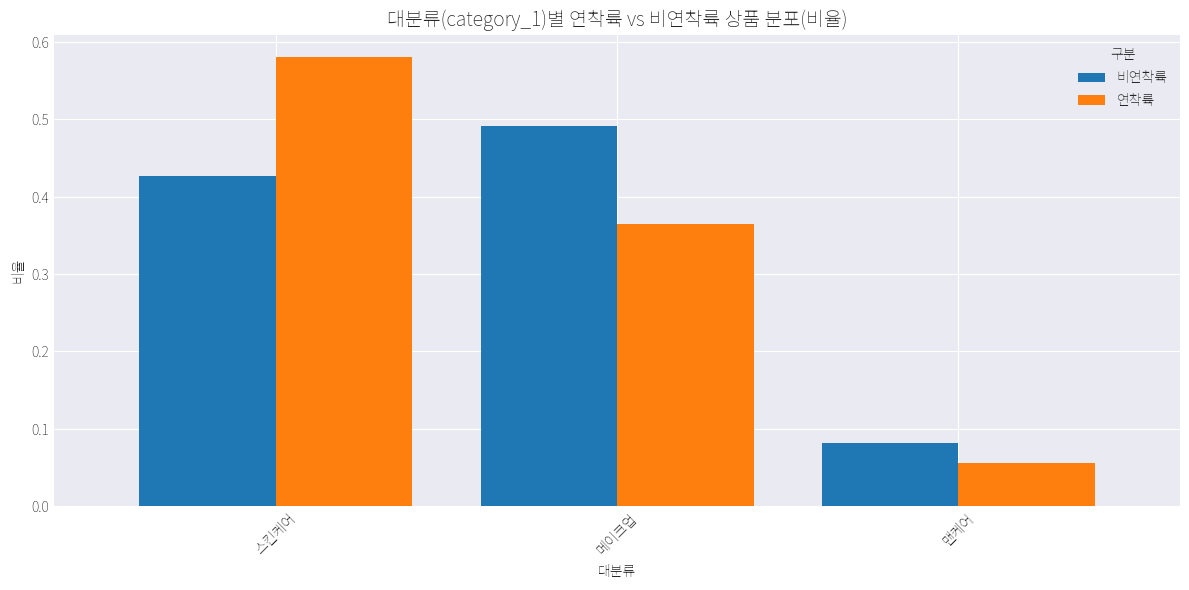

,비연착륙,연착륙
category_1,,
스킨케어,0.426908,0.580110
메이크업,0.491591,0.364641
맨케어,0.081501,0.055249


In [37]:
# -------------------------
# 1. 교차표 (비율 기준)
# -------------------------
cat1_dist = (
    pd.crosstab(
        sku_df['category_1'],
        sku_df['is_soft_success'],
        normalize='columns'
    )
)

cat1_dist.columns = ['비연착륙', '연착륙']
cat1_dist = cat1_dist.sort_values('연착륙', ascending=False)

# -------------------------
# 2. 시각화
# -------------------------
plt.figure(figsize=(12, 6))

cat1_dist.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8
)

plt.title('대분류(category_1)별 연착륙 vs 비연착륙 상품 분포(비율)', fontsize=14)
plt.xlabel('대분류')
plt.ylabel('비율')
plt.xticks(rotation=45)
plt.legend(title='구분')
plt.tight_layout()
plt.show()

cat1_dist

In [38]:
cat2_table = pd.crosstab(
    sku_df['category_2'],
    sku_df['is_soft_success']
)

chi2, p, dof, expected = chi2_contingency(cat2_table)

print("[중분류(category_2) × 연착륙 성공 여부 카이제곱 검정]")
print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

if p < 0.05:
    print("\n결론: 중분류에 따라 연착륙 성공 여부 분포는 유의하게 다르다.")
else:
    print("\n결론: 중분류 차이는 유의하지 않다.")

[중분류(category_2) × 연착륙 성공 여부 카이제곱 검정]
chi2 = 77.3414, p = 3.4795e-11

결론: 중분류에 따라 연착륙 성공 여부 분포는 유의하게 다르다.


<Figure size 1200x600 with 0 Axes>

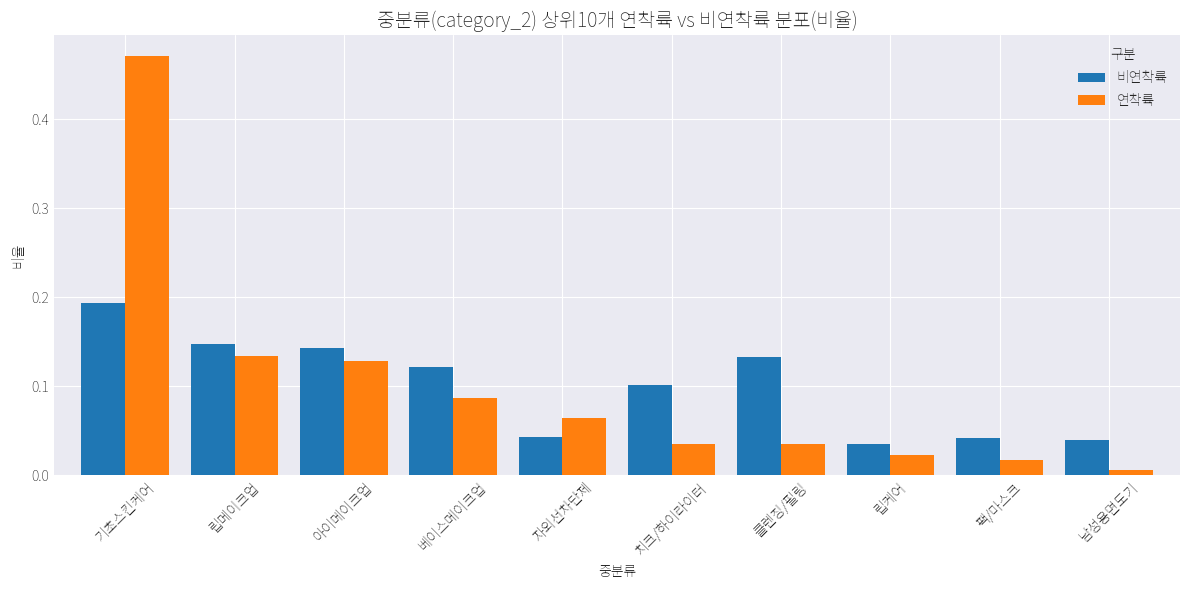

,비연착륙,연착륙
category_2,,
기초스킨케어,0.193505,0.470930
립메이크업,0.147497,0.133721
아이메이크업,0.143437,0.127907
베이스메이크업,0.121786,0.087209
자외선차단제,0.043302,0.063953
치크/하이라이터,0.101488,0.034884
클렌징/필링,0.132612,0.034884
립케어,0.035183,0.023256
팩/마스크,0.041949,0.017442


In [39]:
# -------------------------
# 1. 중분류 빈도 상위 10개 추출
# -------------------------
top_cat2 = (
    sku_df['category_2']
    .value_counts()
    .head(10)
    .index
)

subset = sku_df[sku_df['category_2'].isin(top_cat2)]

cat2_dist = (
    pd.crosstab(
        subset['category_2'],
        subset['is_soft_success'],
        normalize='columns'
    )
)

cat2_dist.columns = ['비연착륙', '연착륙']
cat2_dist = cat2_dist.sort_values('연착륙', ascending=False)

# -------------------------
# 2. 시각화
# -------------------------
plt.figure(figsize=(12, 6))

cat2_dist.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8
)

plt.title('중분류(category_2) 상위10개 연착륙 vs 비연착륙 분포(비율)', fontsize=14)
plt.xlabel('중분류')
plt.ylabel('비율')
plt.xticks(rotation=45)
plt.legend(title='구분')
plt.tight_layout()
plt.show()

cat2_dist

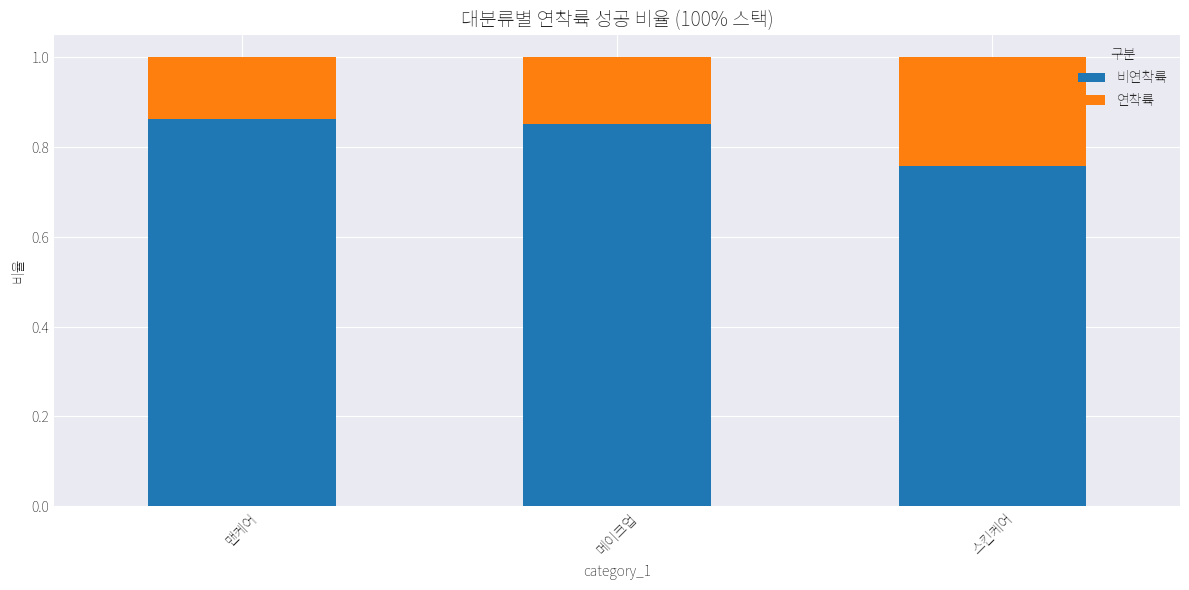

,비연착륙,연착륙
category_1,,
맨케어,0.863014,0.136986
메이크업,0.852018,0.147982
스킨케어,0.758621,0.241379


In [40]:
cat1_stack = (
    pd.crosstab(
        sku_df['category_1'],
        sku_df['is_soft_success'],
        normalize='index'
    )
)

cat1_stack.columns = ['비연착륙', '연착륙']

cat1_stack.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('대분류별 연착륙 성공 비율 (100% 스택)', fontsize=14)
plt.ylabel('비율')
plt.xticks(rotation=45)
plt.legend(title='구분')
plt.tight_layout()
plt.show()

cat1_stack

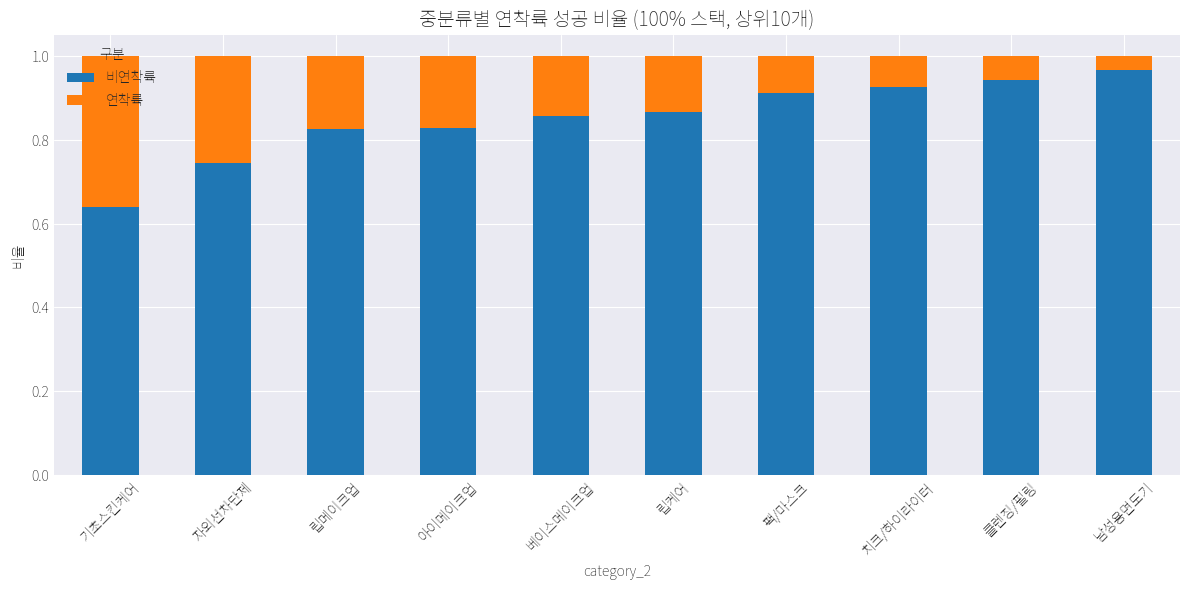

,비연착륙,연착륙
category_2,,
기초스킨케어,0.638393,0.361607
자외선차단제,0.744186,0.255814
립메이크업,0.825758,0.174242
아이메이크업,0.828125,0.171875
베이스메이크업,0.857143,0.142857
립케어,0.866667,0.133333
팩/마스크,0.911765,0.088235
치크/하이라이터,0.925926,0.074074
클렌징/필링,0.942308,0.057692


In [41]:
# -------------------------
# 1. 중분류 상위 10개 선택
# -------------------------
top_cat2 = (
    sku_df['category_2']
    .value_counts()
    .head(10)
    .index
)

subset = sku_df[sku_df['category_2'].isin(top_cat2)]

# -------------------------
# 2. 100% 스택 비율 테이블 생성
# -------------------------
cat2_stack = (
    pd.crosstab(
        subset['category_2'],
        subset['is_soft_success'],
        normalize='index'
    )
)

cat2_stack.columns = ['비연착륙', '연착륙']

# 연착륙 비율 높은 순으로 정렬
cat2_stack = cat2_stack.sort_values('연착륙', ascending=False)

# -------------------------
# 3. 시각화
# -------------------------
cat2_stack.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('중분류별 연착륙 성공 비율 (100% 스택, 상위10개)', fontsize=14)
plt.ylabel('비율')
plt.xticks(rotation=45)
plt.legend(title='구분')
plt.tight_layout()
plt.show()

cat2_stack

In [42]:
from scipy.stats import ttest_ind

soft = sku_df.loc[sku_df['is_soft_success']==1, '평균평점'].dropna()
nonsoft = sku_df.loc[sku_df['is_soft_success']==0, '평균평점'].dropna()

t, p = ttest_ind(soft, nonsoft, equal_var=False)

print("[SKU 평균 평점 차이 Welch t-test]")
print(f"t = {t:.4f}, p = {p:.4e}")

print(f"연착륙 평균: {soft.mean():.3f}")
print(f"비연착륙 평균: {nonsoft.mean():.3f}")

[SKU 평균 평점 차이 Welch t-test]
t = 4.0836, p = 5.2884e-05
연착륙 평균: 4.716
비연착륙 평균: 4.676


In [43]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

results = []

for col in aspect_cols:
    g1 = sku_df.loc[sku_df['is_soft_success']==1, col].dropna()
    g0 = sku_df.loc[sku_df['is_soft_success']==0, col].dropna()
    
    t, p = ttest_ind(g1, g0, equal_var=False)
    
    results.append({
        '변수': col,
        '연착륙평균': g1.mean(),
        '비연착륙평균': g0.mean(),
        '차이(연-비)': g1.mean() - g0.mean(),
        'p값': p
    })

res_df = pd.DataFrame(results)

# FDR 보정
reject, p_adj, _, _ = multipletests(res_df['p값'], method='fdr_bh')

res_df['p(FDR)'] = p_adj
res_df['유의(FDR<0.05)'] = reject

res_df = res_df.sort_values('차이(연-비)', ascending=False)

print("[SKU 단위 감성 평균 차이]")
display(res_df.round(4))

[SKU 단위 감성 평균 차이]


,변수,연착륙평균,비연착륙평균,차이(연-비),p값,p(FDR),유의(FDR<0.05)
5,편의[긍정],0.2775,0.2386,0.0389,0.0001,0.0010,True
1,품질[긍정],0.5632,0.5282,0.0349,0.0003,0.0014,True
2,품질[부정],0.0867,0.0718,0.0148,0.0290,0.0813,False
0,가성비,0.1961,0.1852,0.0109,0.1633,0.2286,False
9,희소성,0.0148,0.0127,0.0021,0.1055,0.1846,False
8,물류[부정],0.0104,0.0089,0.0015,0.0967,0.1846,False
11,로드샵브랜드,0.0121,0.0115,0.0006,0.7260,0.7260,False
13,고가브랜드,0.0005,0.0004,0.0001,0.6146,0.6619,False
4,심미[부정],0.0005,0.0008,-0.0003,0.0727,0.1696,False
12,브랜드개념,0.0070,0.0076,-0.0005,0.3860,0.4504,False


In [63]:
from sklearn.linear_model import LogisticRegression

X = sku_df[aspect_cols + ['price','review_count','engagement_score']].fillna(0)
y = sku_df['is_soft_success']

model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X, y)

coef = pd.Series(model.coef_[0], index=X.columns)
odds = np.exp(coef)

model_table = (
    pd.DataFrame({
        '계수': coef,
        '오즈비': odds
    })
    .sort_values('계수', ascending=False)
)

print("[SKU 단위 연착륙 성공 예측 모델]")
display(model_table.round(4))

[SKU 단위 연착륙 성공 예측 모델]


,계수,오즈비
가성비,1.9078,6.7381
편의[긍정],1.5126,4.5387
품질[긍정],1.3468,3.8449
로드샵브랜드,0.4149,1.5142
희소성,0.1023,1.1078
품질[부정],0.0426,1.0435
고가브랜드,0.0299,1.0303
engagement_score,0.0010,1.0010
심미[부정],0.0002,1.0002
price,0.0001,1.0001


## 식약처 분석

In [64]:
df_mfds = pd.read_parquet(INGRED_DIR / "products_mfds.parquet")

print(f"[데이터 로드 완료]")
print(f"총 리뷰 수: {len(df_mfds):,}개")
print(f"컬럼: {df_mfds.columns.tolist()}")
print(f"\n[샘플 데이터]")
df_mfds.head()


[데이터 로드 완료]
총 리뷰 수: 259개
컬럼: ['product_code', 'search_key', 'mfds_matched', 'mfds_total_count', 'mfds_item_name', 'mfds_entp_name', 'mfds_report_seq', 'mfds_report_date', 'mfds_item_ph', 'mfds_target_flag', 'mfds_target_flag_name', 'mfds_std_code', 'mfds_std_name', 'mfds_ee_code', 'mfds_ee_name', 'mfds_spf', 'mfds_pa', 'mfds_water_proofing_flag', 'mfds_water_proofing_name', 'mfds_report_flag_code', 'mfds_report_flag_name', 'mfds_ethanol_over_yn', 'is_whitening', 'is_anti_wrinkle', 'is_sunscreen', 'is_hair_color', 'is_hair_removal', 'is_acne', 'is_atopic', 'is_stretch_marks', 'is_hair_loss', 'is_eye_wrinkle', 'is_tanning']

[샘플 데이터]


,product_code,search_key,mfds_matched,mfds_total_count,mfds_item_name,mfds_entp_name,mfds_report_seq,mfds_report_date,mfds_item_ph,mfds_target_flag,...,is_anti_wrinkle,is_sunscreen,is_hair_color,is_hair_removal,is_acne,is_atopic,is_stretch_marks,is_hair_loss,is_eye_wrinkle,is_tanning
0,1056665,해서린스팟케어클리어젤,True,1,해서린스팟케어클리어젤,주식회사디와이디,2021014801.0,20210430,5.3,1,...,False,False,False,False,False,False,False,False,False,False
1,1061480,드롭비컬러즈커버픽파운데이션리뉴,True,2,드롭비컬러즈커버픽파운데이션리뉴02내추럴베이지,(주)더샘인터내셔날,2025002079.0,20250110,6.3,3,...,False,True,False,False,False,False,False,False,False,False
2,1061477,드롭비컬러즈커버픽파운데이션리뉴,True,2,드롭비컬러즈커버픽파운데이션리뉴02내추럴베이지,(주)더샘인터내셔날,2025002079.0,20250110,6.3,3,...,False,True,False,False,False,False,False,False,False,False
3,1048583,드롭비탄탄광채앰플,True,1,드롭비탄탄광채앰플,(주)더샘인터내셔날,2023030465.0,20230728,6.50,1,...,False,False,False,False,False,False,False,False,False,False
4,1061482,드롭비컬러즈베일스킨톤업베이스,True,1,드롭비컬러즈베일스킨톤업베이스,(주)더샘인터내셔날,2025002075.0,20250110,6.3,3,...,False,True,False,False,False,False,False,False,False,False


In [79]:
# -----------------------------
# 1) MFDS 중복 제거 (product_code 단위로 1개만)
#    - mfds_report_date가 "최근"일수록 우선으로 쓰려면 ascending=False 권장
#    - (현재는 sort_values 오름차순 → 가장 오래된 신고가 남음)
# -----------------------------
mfds_sku = (
    df_mfds
    .copy()
)

# report_date 정리: 숫자/문자 섞임 대비
mfds_sku['mfds_report_date'] = pd.to_numeric(mfds_sku['mfds_report_date'], errors='coerce')

# "최신 신고"를 대표값으로 선택
mfds_sku = (
    mfds_sku
    .sort_values('mfds_report_date', ascending=False)
    .drop_duplicates(subset=['product_code'], keep='first')
)

print("[MFDS 데이터 중복 제거 완료]")
print(f"- MFDS 원본 행 수: {len(df_mfds):,}개")
print(f"- MFDS SKU 수(중복 제거 후): {mfds_sku['product_code'].nunique():,}개")

# -----------------------------
# 2) SKU 테이블과 병합
# -----------------------------
sku_m = sku_df.merge(
    mfds_sku,
    on='product_code',
    how='left'
)

mfds_matched_cnt = sku_m['mfds_matched'].fillna(False).sum()
mfds_match_ratio = mfds_matched_cnt / len(sku_m) * 100

print("\n[SKU × MFDS 병합 완료]")
print(f"- 전체 SKU 수: {len(sku_m):,}개")
print(f"- MFDS 매칭 SKU 수: {int(mfds_matched_cnt):,}개 ({mfds_match_ratio:.1f}%)")
print("※ MFDS는 '매칭된 SKU만' 존재하므로, 미매칭 SKU는 MFDS 컬럼이 결측(NaN)으로 남는 것이 정상임.")

[MFDS 데이터 중복 제거 완료]
- MFDS 원본 행 수: 259개
- MFDS SKU 수(중복 제거 후): 259개

[SKU × MFDS 병합 완료]
- 전체 SKU 수: 954개
- MFDS 매칭 SKU 수: 261개 (27.4%)
※ MFDS는 '매칭된 SKU만' 존재하므로, 미매칭 SKU는 MFDS 컬럼이 결측(NaN)으로 남는 것이 정상임.


In [80]:
import numpy as np
import pandas as pd

print("[전처리] dtype 정리 및 기능성 파생변수 생성")

# 1) is_soft_success: 0/1 int로 강제
sku_m['is_soft_success'] = pd.to_numeric(sku_m['is_soft_success'], errors='coerce').fillna(0).astype(int)

# 2) 기능성 컬럼들: True/False/NaN + 문자열 True/False까지 커버
func_cols = [
    'is_whitening','is_anti_wrinkle','is_sunscreen',
    'is_acne','is_atopic','is_hair_loss','is_eye_wrinkle',
    'is_tanning','is_hair_color','is_hair_removal',
    'is_stretch_marks'
]

# MFDS 미매칭 SKU는 NaN이므로 False로 처리
for c in func_cols:
    if c in sku_m.columns:
        sku_m[c] = (
            sku_m[c]
            .replace({'True': True, 'False': False, 'TRUE': True, 'FALSE': False, 1: True, 0: False})
            .fillna(False)
            .astype(bool)
        )
    else:
        sku_m[c] = False  # 혹시 컬럼이 아예 없을 경우 안전장치

# 3) 파생 플래그
sku_m['is_functional_main'] = sku_m[['is_whitening','is_anti_wrinkle','is_sunscreen']].any(axis=1)
sku_m['is_functional_main_int'] = sku_m['is_functional_main'].astype(int)

sku_m['is_functional_any'] = sku_m[func_cols].any(axis=1)
sku_m['is_functional_any_int'] = sku_m['is_functional_any'].astype(int)

sku_m['functional_count'] = sku_m[func_cols].sum(axis=1).astype(int)

# 4) pH: numeric으로 강제
sku_m['mfds_item_ph'] = pd.to_numeric(sku_m['mfds_item_ph'], errors='coerce')

# 5) price: 혹시 쉼표/문자 섞임 대비 (안전)
sku_m['price'] = pd.to_numeric(sku_m['price'], errors='coerce')

# -----------------------------
# 리포트
# -----------------------------
total_sku = len(sku_m)
soft_cnt = (sku_m['is_soft_success'] == 1).sum()
soft_ratio = soft_cnt / total_sku * 100

mfds_match_cnt = sku_m['mfds_matched'].fillna(False).sum()
mfds_match_ratio = mfds_match_cnt / total_sku * 100

print("\n[요약]")
print(f"- 전체 SKU: {total_sku:,}개")
print(f"- 연착륙 SKU: {soft_cnt:,}개 ({soft_ratio:.1f}%)")
print(f"- MFDS 매칭 SKU: {int(mfds_match_cnt):,}개 ({mfds_match_ratio:.1f}%)")

print("\n[dtype 점검]")
print("is_soft_success:", sku_m['is_soft_success'].dtype)
print("is_functional_main:", sku_m['is_functional_main'].dtype)
print("mfds_item_ph:", sku_m['mfds_item_ph'].dtype)
print("price:", sku_m['price'].dtype)

print("\n[결측 점검]")
print(f"- mfds_item_ph 결측 비율: {sku_m['mfds_item_ph'].isna().mean():.1%}")
print(f"- price 결측 비율: {sku_m['price'].isna().mean():.1%}")

[전처리] dtype 정리 및 기능성 파생변수 생성

[요약]
- 전체 SKU: 954개
- 연착륙 SKU: 181개 (19.0%)
- MFDS 매칭 SKU: 261개 (27.4%)

[dtype 점검]
is_soft_success: int64
is_functional_main: bool
mfds_item_ph: float64
price: int64

[결측 점검]
- mfds_item_ph 결측 비율: 75.4%
- price 결측 비율: 0.0%


In [83]:
func_compare = (
    sku_m
    .groupby('is_soft_success')['is_functional_main_int']
    .mean()
    .rename({0: '비연착륙', 1: '연착륙'})
)

display(func_compare)

soft_rate = func_compare.loc['연착륙'] * 100 if '연착륙' in func_compare.index else np.nan
nonsoft_rate = func_compare.loc['비연착륙'] * 100 if '비연착륙' in func_compare.index else np.nan

print("\n[요약]")
print(f"- 연착륙 SKU의 기능성(미백/주름/자외선) 비율: {soft_rate:.1f}%")
print(f"- 비연착륙 SKU의 기능성(미백/주름/자외선) 비율: {nonsoft_rate:.1f}%")

if np.isfinite(soft_rate) and np.isfinite(nonsoft_rate):
    diff = soft_rate - nonsoft_rate
    print(f"- 차이(연착륙 - 비연착륙): {diff:+.1f}%p")
    print("연착륙 집단에서 기능성 비중이 더 높게 나타났다.")

is_soft_success
비연착륙    0.254851
연착륙     0.353591
Name: is_functional_main_int, dtype: float64


[요약]
- 연착륙 SKU의 기능성(미백/주름/자외선) 비율: 35.4%
- 비연착륙 SKU의 기능성(미백/주름/자외선) 비율: 25.5%
- 차이(연착륙 - 비연착륙): +9.9%p
연착륙 집단에서 기능성 비중이 더 높게 나타났다.


In [84]:
import scipy.stats as stats
import pandas as pd

ct = pd.crosstab(
    sku_m['is_soft_success'],
    sku_m['is_functional_main']
)

display(ct)

# 카이제곱은 "행/열에 0만 있는 경우" 예외가 날 수 있어 안전 처리
if ct.shape == (2, 2) and (ct.values.sum() > 0) and (ct.sum(axis=0).min() > 0) and (ct.sum(axis=1).min() > 0):
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    print("\n[연착륙 성공 여부 × 기능성 여부 카이제곱 검정]")
    print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

    if p < 0.05:
        print("\n결론: 기능성 여부에 따라 연착륙 성공 여부 분포는 유의하게 다르다.")
    else:
        print("\n결론: 기능성 여부에 따른 연착륙 분포 차이는 유의하지 않다.")
else:
    print("\n[연착륙 성공 여부 × 기능성 여부 카이제곱 검정]")
    print("주의: 분할표가 2x2가 아니거나, 특정 행/열의 합이 0이라 검정을 수행할 수 없습니다.")

is_functional_main,False,True
is_soft_success,,
0,576,197
1,117,64



[연착륙 성공 여부 × 기능성 여부 카이제곱 검정]
chi2 = 6.7065, p = 9.6060e-03

결론: 기능성 여부에 따라 연착륙 성공 여부 분포는 유의하게 다르다.


In [86]:
price_compare = (
    sku_m
    .groupby('is_functional_main_int')['price']
    .mean()
    .rename({0: '비기능성', 1: '기능성(미백/주름/자외선)'})
)

display(price_compare)

p0 = price_compare.loc['비기능성'] if '비기능성' in price_compare.index else np.nan
p1 = price_compare.loc['기능성(미백/주름/자외선)'] if '기능성(미백/주름/자외선)' in price_compare.index else np.nan

print("\n[요약]")
print(f"- 비기능성 평균 가격: {p0:,.0f}원")
print(f"- 기능성 평균 가격: {p1:,.0f}원")

if np.isfinite(p0) and np.isfinite(p1) and p0 > 0:
    print(f"- 기능성/비기능성 가격 비율: {p1/p0:.2f}배")


is_functional_main_int
비기능성              3443.001443
기능성(미백/주름/자외선)    4446.360153
Name: price, dtype: float64


[요약]
- 비기능성 평균 가격: 3,443원
- 기능성 평균 가격: 4,446원
- 기능성/비기능성 가격 비율: 1.29배


In [88]:
soft_df = sku_m[sku_m['is_soft_success'] == 1].copy()

soft_cnt = len(soft_df)
soft_func_rate = soft_df['is_functional_main_int'].mean() * 100 if soft_cnt > 0 else np.nan

print("[연착륙 SKU 요약]")
print(f"- 연착륙 SKU 수: {soft_cnt:,}개")
print(f"- 연착륙 중 기능성(미백/주름/자외선) 비율: {soft_func_rate:.1f}%")

[연착륙 SKU 요약]
- 연착륙 SKU 수: 181개
- 연착륙 중 기능성(미백/주름/자외선) 비율: 35.4%


In [89]:
import scipy.stats as stats
import pandas as pd

skincare_df = sku_m[sku_m['category_1'] == '스킨케어'].copy()

ct_skin = pd.crosstab(
    skincare_df['is_soft_success'],
    skincare_df['is_functional_main']
)

print("[스킨케어 한정] 연착륙 × 기능성 분할표")
display(ct_skin)

# 카이제곱 가능 여부 체크
if ct_skin.shape == (2, 2) and (ct_skin.values.sum() > 0) and (ct_skin.sum(axis=0).min() > 0) and (ct_skin.sum(axis=1).min() > 0):
    chi2, p, dof, expected = stats.chi2_contingency(ct_skin)
    print("\n[스킨케어 한정 카이제곱 검정]")
    print(f"chi2 = {chi2:.4f}, p = {p:.4e}")

    if p < 0.05:
        print("\n결론: (스킨케어 내에서) 기능성 여부에 따라 연착륙 분포는 유의하게 다르다.")
    else:
        print("\n결론: (스킨케어 내에서) 기능성 여부에 따른 연착륙 분포 차이는 유의하지 않다.")
else:
    print("\n주의: 분할표가 2x2가 아니거나, 특정 행/열 합이 0이라 검정을 수행할 수 없습니다.")

[스킨케어 한정] 연착륙 × 기능성 분할표


is_functional_main,False,True
is_soft_success,,
0,194,136
1,51,54



[스킨케어 한정 카이제곱 검정]
chi2 = 2.9771, p = 8.4449e-02

결론: (스킨케어 내에서) 기능성 여부에 따른 연착륙 분포 차이는 유의하지 않다.


In [91]:
ph_compare = (
    sku_m
    .groupby('is_soft_success')['mfds_item_ph']
    .mean()
    .rename({0: '비연착륙', 1: '연착륙'})
)

display(ph_compare)

ph_soft = ph_compare.loc['연착륙'] if '연착륙' in ph_compare.index else np.nan
ph_non = ph_compare.loc['비연착륙'] if '비연착륙' in ph_compare.index else np.nan

print("\n[요약]")
print(f"- 연착륙 SKU 평균 pH: {ph_soft:.2f}" if np.isfinite(ph_soft) else "- 연착륙 SKU 평균 pH: (데이터 부족)")
print(f"- 비연착륙 SKU 평균 pH: {ph_non:.2f}" if np.isfinite(ph_non) else "- 비연착륙 SKU 평균 pH: (데이터 부족)")

is_soft_success
비연착륙    6.498793
연착륙     6.551311
Name: mfds_item_ph, dtype: float64


[요약]
- 연착륙 SKU 평균 pH: 6.55
- 비연착륙 SKU 평균 pH: 6.50


[pH 범주 분포(전체)]


,SKU 수,비중(%)
ph_bucket,,
산성(3~4.5),1,0.1
약산성(4.5~6.5),105,11.0
중성(6.5~7.5),120,12.6
알칼리성(>7.5),9,0.9
기타(범주 외),0,0.0
결측,719,75.4



[pH 범주 분포(연착륙 여부별)] - 개수


ph_bucket,산성(3~4.5),약산성(4.5~6.5),중성(6.5~7.5),알칼리성(>7.5),기타(범주 외),결측
is_soft_success,,,,,,
비연착륙,1,78,87,8,0,599
연착륙,0,27,33,1,0,120



[pH 범주 분포(연착륙 여부별)] - 비중(%)


ph_bucket,산성(3~4.5),약산성(4.5~6.5),중성(6.5~7.5),알칼리성(>7.5),기타(범주 외),결측
is_soft_success,,,,,,
비연착륙,0.1,10.1,11.3,1.0,0.0,77.5
연착륙,0.0,14.9,18.2,0.6,0.0,66.3


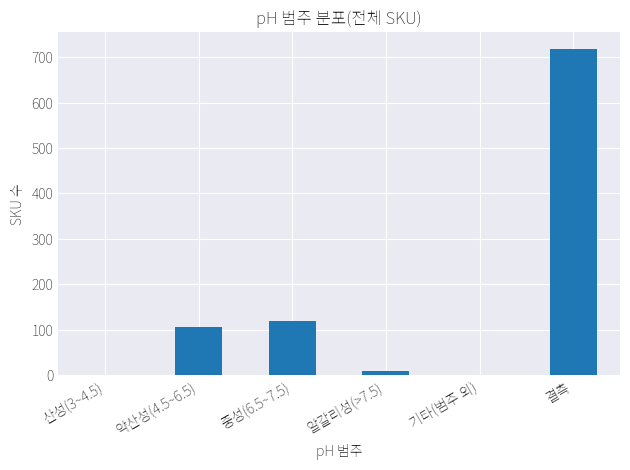

<Figure size 640x480 with 0 Axes>

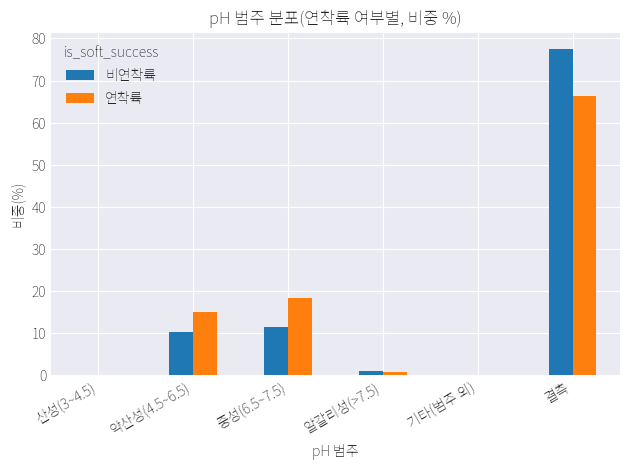


[요약]
- 전체 SKU 954개 중 pH 범주 판별 가능(4대 범주) SKU는 235개입니다.
  (결측/기타는 MFDS 미매칭 또는 범주 정의 밖 값(예: 3 미만)이 포함될 수 있습니다.)
- (pH 판별 가능 SKU 기준) 약산성 제품 비중은 연착륙 44.3%, 비연착륙 44.8%로, 차이는 -0.5%p 입니다.


In [99]:
# =========================
# 1) pH 범주화 함수
# =========================
def ph_bucket(x, neutral_tol=0.05):
    """
    산성:      3 <= X < 4.5
    약산성:    4.5 <= X < 6.5
    중성:      6.5 <= X <= 7.5   (※ 기존 정의에서 비어 있던 6.5~7 구간을 '중성에 근접'으로 흡수)
    알칼리성:  X > 7.5
    그 외:     범주 정의 밖(예: 3 미만 등)
    """
    if pd.isna(x):
        return '결측'
    try:
        x = float(x)
    except:
        return '결측'
    
    if 3 <= x < 4.5:
        return '산성(3~4.5)'
    elif 4.5 <= x < 6.5:
        return '약산성(4.5~6.5)'
    elif 6.5 <= x <= 7.5:
        return '중성(6.5~7.5)'
    elif x > 7.5:
        return '알칼리성(>7.5)'
    else:
        return '기타(범주 외)'  # 3 미만 등

# =========================
# 2) pH 범주 컬럼 생성
# =========================
sku_m['ph_bucket'] = sku_m['mfds_item_ph'].apply(ph_bucket)

# 보기 좋게 범주 순서 고정
bucket_order = ['산성(3~4.5)', '약산성(4.5~6.5)', '중성(6.5~7.5)', '알칼리성(>7.5)', '기타(범주 외)', '결측']
sku_m['ph_bucket'] = pd.Categorical(sku_m['ph_bucket'], categories=bucket_order, ordered=True)

# =========================
# 3) 요약 테이블
# =========================
# 전체 분포
overall_ct = sku_m['ph_bucket'].value_counts(dropna=False).reindex(bucket_order, fill_value=0)
overall_ratio = (overall_ct / overall_ct.sum() * 100).round(1)

summary_overall = pd.DataFrame({
    'SKU 수': overall_ct,
    '비중(%)': overall_ratio
})

print("[pH 범주 분포(전체)]")
display(summary_overall)

# 연착륙/비연착륙별 분포(비중)
by_soft_ct = pd.crosstab(sku_m['is_soft_success'], sku_m['ph_bucket']).reindex(columns=bucket_order, fill_value=0)
by_soft_ratio = (by_soft_ct.div(by_soft_ct.sum(axis=1).replace(0, np.nan), axis=0) * 100).round(1)

# 라벨링
by_soft_ct.index = by_soft_ct.index.map({0: '비연착륙', 1: '연착륙'})
by_soft_ratio.index = by_soft_ratio.index.map({0: '비연착륙', 1: '연착륙'})

print("\n[pH 범주 분포(연착륙 여부별)] - 개수")
display(by_soft_ct)

print("\n[pH 범주 분포(연착륙 여부별)] - 비중(%)")
display(by_soft_ratio)

# =========================
# 4) 시각화 1: 전체 분포(Count)
# =========================
plt.figure()
overall_ct.plot(kind='bar')
plt.title('pH 범주 분포(전체 SKU)')
plt.xlabel('pH 범주')
plt.ylabel('SKU 수')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# =========================
# 5) 시각화 2: 연착륙 여부별 분포(비중 %)
#    - 그룹별(연착륙/비연착륙) 100% 기준 비교
# =========================
plt.figure()
by_soft_ratio.T.plot(kind='bar')
plt.title('pH 범주 분포(연착륙 여부별, 비중 %)')
plt.xlabel('pH 범주')
plt.ylabel('비중(%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# =========================
# 6) 요약 설명(자동 문장)
# =========================
# pH 데이터가 있는 SKU만 기준으로 “산성/약산성/중성/알칼리성” 비중 비교도 같이 출력
valid_mask = sku_m['ph_bucket'].isin(['산성(3~4.5)', '약산성(4.5~6.5)', '중성(6.5~7.5)', '알칼리성(>7.5)'])
valid_df = sku_m[valid_mask].copy()

print("\n[요약]")
print(f"- 전체 SKU {len(sku_m):,}개 중 pH 범주 판별 가능(4대 범주) SKU는 {len(valid_df):,}개입니다.")
print("  (결측/기타는 MFDS 미매칭 또는 범주 정의 밖 값(예: 3 미만)이 포함될 수 있습니다.)")

if len(valid_df) > 0:
    valid_by_soft = pd.crosstab(valid_df['is_soft_success'], valid_df['ph_bucket'])
    valid_by_soft_ratio = (valid_by_soft.div(valid_by_soft.sum(axis=1).replace(0, np.nan), axis=0) * 100).round(1)
    valid_by_soft.index = valid_by_soft.index.map({0: '비연착륙', 1: '연착륙'})
    valid_by_soft_ratio.index = valid_by_soft_ratio.index.map({0: '비연착륙', 1: '연착륙'})

    # 핵심 비교: 약산성 비중 차이(예시로 가장 실무적으로 많이 쓰이는 범주)
    if '연착륙' in valid_by_soft_ratio.index and '비연착륙' in valid_by_soft_ratio.index and '약산성(4.5~6.5)' in valid_by_soft_ratio.columns:
        soft_weak = valid_by_soft_ratio.loc['연착륙', '약산성(4.5~6.5)']
        non_weak = valid_by_soft_ratio.loc['비연착륙', '약산성(4.5~6.5)']
        diff = soft_weak - non_weak
        print(f"- (pH 판별 가능 SKU 기준) 약산성 제품 비중은 연착륙 {soft_weak:.1f}%, 비연착륙 {non_weak:.1f}%로, 차이는 {diff:+.1f}%p 입니다.")
    else:
        print("- 연착륙/비연착륙 표본이 부족하거나 약산성 범주가 없어, 범주 간 비중 차이 요약을 생략합니다.")
else:
    print("- pH 데이터가 충분하지 않아 범주 기반 해석을 진행할 수 없습니다.")

In [98]:


# =========================================
# 1) 검정용 데이터 준비 (결측/기타 처리)
#   - 4대 범주만 사용: 산성/약산성/중성/알칼리성
#   - '기타(범주 외)', '결측'은 제외 (범주 정의에서 벗어난 값이 섞여 있어 해석이 애매함)
# =========================================
ph4 = ['산성(3~4.5)', '약산성(4.5~6.5)', '중성(≈7)', '알칼리성(>7)']

df_ph_test = sku_m[
    (sku_m['is_soft_success'].isin([0, 1])) &
    (sku_m['ph_bucket'].isin(ph4))
].copy()

# 표본 수 체크
n0 = (df_ph_test['is_soft_success'] == 0).sum()
n1 = (df_ph_test['is_soft_success'] == 1).sum()

print("[pH 범주(4대) × 연착륙 여부] 유의성 검정 준비")
print(f"- 검정 포함 표본: {len(df_ph_test):,}개")
print(f"- 비연착륙(n=0): {n0:,}개, 연착륙(n=1): {n1:,}개")

# =========================================
# 2) 분할표 생성
# =========================================
ct_ph = pd.crosstab(df_ph_test['is_soft_success'], df_ph_test['ph_bucket']).reindex(columns=ph4, fill_value=0)
ct_ph.index = ct_ph.index.map({0: '비연착륙', 1: '연착륙'})

print("\n[pH(4대 범주) 분할표]")
display(ct_ph)

# =========================================
# 3) 카이제곱 검정 (범주형 분포 차이)
# =========================================
# 카이제곱 요건 체크: 모든 열 합 > 0, 모든 행 합 > 0
if (ct_ph.values.sum() > 0) and (ct_ph.sum(axis=0).min() > 0) and (ct_ph.sum(axis=1).min() > 0):
    chi2, p, dof, expected = stats.chi2_contingency(ct_ph)
    n = ct_ph.values.sum()
    k = min(ct_ph.shape)  # Cramer's V 계산에 필요
    cramers_v = np.sqrt(chi2 / (n * (k - 1))) if k > 1 else np.nan

    print("\n[pH(4대 범주) × 연착륙 여부 카이제곱 검정]")
    print(f"chi2 = {chi2:.4f}, dof = {dof}, p = {p:.4e}")
    print(f"Cramer's V = {cramers_v:.3f}")

    if p < 0.05:
        print("\n결론: 연착륙 여부에 따라 pH 범주 분포는 유의하게 다르다.")
    else:
        print("\n결론: 연착륙 여부에 따른 pH 범주 분포 차이는 유의하지 않다.")
else:
    print("\n[카이제곱 검정 불가]")
    print("주의: 특정 범주의 표본이 0이거나(열 합=0), 특정 그룹 표본이 0이라(행 합=0) 검정을 수행할 수 없습니다.")



[pH 범주(4대) × 연착륙 여부] 유의성 검정 준비
- 검정 포함 표본: 180개
- 비연착륙(n=0): 134개, 연착륙(n=1): 46개

[pH(4대 범주) 분할표]


ph_bucket,산성(3~4.5),약산성(4.5~6.5),중성(≈7),알칼리성(>7)
is_soft_success,,,,
비연착륙,1,78,24,31
연착륙,0,27,10,9



[pH(4대 범주) × 연착륙 여부 카이제곱 검정]
chi2 = 0.8067, dof = 3, p = 8.4786e-01
Cramer's V = 0.067

결론: 연착륙 여부에 따른 pH 범주 분포 차이는 유의하지 않다.


In [ ]:
# ----------------------------
# 1) 양 극단 SKU 추출
# ----------------------------
extreme_df = sku_m[
    sku_m['ph_bucket'].isin(['산성(3~4.5)', '알칼리성(>7.5)'])
].copy()

# 보기 좋게 정렬
extreme_df = extreme_df.sort_values('mfds_item_ph')

cols_to_show = [
    'product_code',
    'brand',
    'name',
    'category_1',
    'category_2',
    'price',
    'likes',
    'is_soft_success',
    'mfds_item_ph'
]

# display(extreme_df[cols_to_show])

# print("\n[요약]")
# print(f"- 산성 SKU 수: {(extreme_df['ph_bucket'] == '산성(3~4.5)').sum()}개")
# print(f"- 알칼리성 SKU 수: {(extreme_df['ph_bucket'] == '알칼리성(>7.5)').sum()}개")

,product_code,brand,name,category_1,category_2,price,likes,is_soft_success,mfds_item_ph
621,1071645,파티온,파티온 노스카나인 트러블패드 4매입,스킨케어,기초스킨케어,1000,1353,0,4.0
284,1064411,잇츠스킨,잇츠스킨 세븐펩타이드콜라겐 크림 50ml,스킨케어,기초스킨케어,5000,3591,0,7.6
334,1046401,과일나라,과일나라 알로에베라 모이스처 아쿠아 수딩 선 에센스 50 g,스킨케어,자외선차단제,3000,2416,0,7.7
834,1072802,케어존 플러스,케어존플러스 모공탄력 부스터샷세럼 45 ml,스킨케어,기초스킨케어,5000,1048,0,7.7
318,1072521,이즈앤트리,이즈앤트리 어니언블레미쉬 퍼플라이트 톤업선크림 40 ml,스킨케어,자외선차단제,5000,948,0,7.8
606,1065045,레시피선몬랩,레시피선몬랩 카밍워터프루프 선스프레이 70 ml,스킨케어,자외선차단제,5000,2885,0,7.8
608,1065046,레시피선몬랩,레시피선몬랩 슈퍼아쿠아 선스프레이 70 ml,스킨케어,자외선차단제,5000,2345,0,7.8
858,1061700,더페이스샵,더페이스샵 스밈 보습밀도 장벽 아이크림 30 ml,스킨케어,기초스킨케어,5000,798,1,7.8
838,1072806,케어존 플러스,케어존플러스 광채탄력 부스터샷세럼 45 ml,스킨케어,기초스킨케어,5000,585,0,8.0
549,1053481,메디필,메디필 엑스트라 슈퍼 9 플러스 아크네 클렌징 폼 100 ml,스킨케어,클렌징/필링,3000,4894,0,10.1



[요약]
- 산성 SKU 수: 1개
- 알칼리성 SKU 수: 9개


## 재료 분석

In [ ]:
df_ing = pd.read_parquet(INGRED_DIR / "products_ingredients_merged.parquet")
if "application_role" not in df_ing.columns and "ingredient_type" in df_ing.columns:
    df_ing = df_ing.rename(columns={"ingredient_type": "application_role"})

print(f"[데이터 로드 완료]")
print(f"총 리뷰 수: {len(df_ing):,}개")
print(f"컬럼: {df_ing.columns.tolist()}")
print(f"\n[샘플 데이터]")
df_ing.head(15)


[데이터 로드 완료]
총 리뷰 수: 27,931개
컬럼: ['product_code', 'name', 'ingredient', 'ingredient_type', 'risk_score', 'allergic', 'application_role']

[샘플 데이터]


,product_code,name,ingredient,ingredient_type,risk_score,allergic,application_role
0,31386,뉴트로지나 립모이스춰,돌콩오일,Vegetable Oil,0,0,Moisturizing
1,31386,뉴트로지나 립모이스춰,비즈왁스,Wax,0,0,Moisturizing
2,31386,뉴트로지나 립모이스춰,오조케라이트,Wax,0,0,Moisturizing
3,31386,뉴트로지나 립모이스춰,카나우바왁스,Wax,0,0,Moisturizing
4,31386,뉴트로지나 립모이스춰,카카오씨버터,Vegetable Oil,0,0,Moisturizing
5,31386,뉴트로지나 립모이스춰,토코페릴아세테이트,Ester,0,0,Moisturizing
6,31386,뉴트로지나 립모이스춰,파라핀,Hydrocarbon,0,0,Base
7,31386,뉴트로지나 립모이스춰,하이드로제네이티드코코넛오일,Vegetable Oil,0,0,Moisturizing
8,41301,메이크업 리무버티슈 60매,글리세린,Polyol,0,0,Moisturizing
9,41301,메이크업 리무버티슈 60매,낫토검,Polymer,0,0,Texture


In [111]:
# =========================
# 1) SKU 단위 리스크 집계
# =========================

sku_ing_summary = (
    df_ing
    .groupby('product_code')
    .agg(
        ingredient_cnt = ('ingredient','count'),
        risk_sum = ('risk_score','sum'),
        risk_mean = ('risk_score','mean'),
        allergic_cnt = ('allergic','sum')
    )
    .reset_index()
)

# 알레르기 비율
sku_ing_summary['allergic_ratio'] = (
    sku_ing_summary['allergic_cnt'] /
    sku_ing_summary['ingredient_cnt']
)

print("[SKU 단위 성분 요약 테이블 생성 완료]")
display(sku_ing_summary.head())

[SKU 단위 성분 요약 테이블 생성 완료]


,product_code,ingredient_cnt,risk_sum,risk_mean,allergic_cnt,allergic_ratio
0,31386,8,0,0.000000,0,0.000000
1,41301,25,2,0.080000,1,0.040000
2,49856,18,12,0.666667,6,0.333333
3,49859,24,12,0.500000,6,0.250000
4,50371,37,7,0.189189,3,0.081081


In [112]:
# sku_m (이미 만들어진 SKU 마스터 테이블)와 병합

sku_m2 = sku_m.merge(
    sku_ing_summary,
    on='product_code',
    how='left'
)

print("[병합 완료]")
print(f"성분 매칭 SKU 수: {sku_m2['ingredient_cnt'].notna().sum():,}개")

[병합 완료]
성분 매칭 SKU 수: 907개


In [114]:
risk_compare = (
    sku_m2
    .groupby('is_soft_success')
    .agg(
        평균_성분수=('ingredient_cnt','mean'),
        평균_risk_sum=('risk_sum','mean'),
        평균_risk_mean=('risk_mean','mean'),
        평균_allergic_cnt=('allergic_cnt','mean'),
        평균_allergic_ratio=('allergic_ratio','mean')
    )
)

risk_compare.index = risk_compare.index.map({0:'비연착륙',1:'연착륙'})

display(risk_compare)

,평균_성분수,평균_risk_sum,평균_risk_mean,평균_allergic_cnt,평균_allergic_ratio
is_soft_success,,,,,
비연착륙,30.678129,2.022008,0.067362,1.034388,0.034646
연착륙,31.994444,2.100000,0.075100,1.050000,0.037844


In [115]:
import scipy.stats as stats

soft = sku_m2[sku_m2['is_soft_success']==1]['risk_mean'].dropna()
nonsoft = sku_m2[sku_m2['is_soft_success']==0]['risk_mean'].dropna()

t_stat, p_val = stats.ttest_ind(soft, nonsoft, equal_var=False)

print("[연착륙 vs 비연착륙 risk_mean 평균 차이 검정]")
print(f"t = {t_stat:.4f}, p = {p_val:.4e}")

if p_val < 0.05:
    print("결론: 두 집단 간 평균 risk_mean 차이는 유의하다.")
else:
    print("결론: 두 집단 간 평균 risk_mean 차이는 유의하지 않다.")

[연착륙 vs 비연착륙 risk_mean 평균 차이 검정]
t = 0.5310, p = 5.9594e-01
결론: 두 집단 간 평균 risk_mean 차이는 유의하지 않다.


<Figure size 640x480 with 0 Axes>

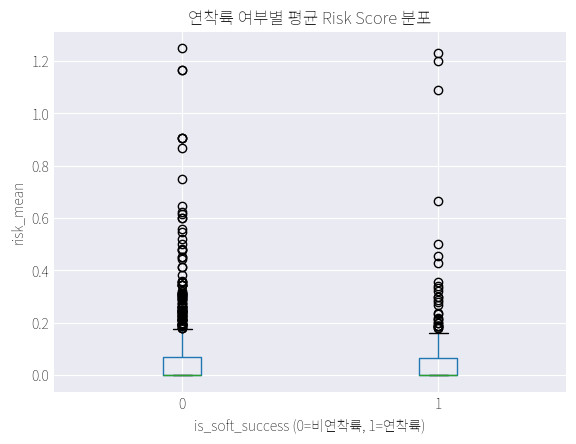

In [116]:
import matplotlib.pyplot as plt

plt.figure()
sku_m2.boxplot(column='risk_mean', by='is_soft_success')
plt.title('연착륙 여부별 평균 Risk Score 분포')
plt.suptitle('')
plt.xlabel('is_soft_success (0=비연착륙, 1=연착륙)')
plt.ylabel('risk_mean')
plt.show()

#### 해석

* risk_mean 은 평균 위험 점수 
* 하지만 소비자는 평균을 보지 않는다. 

* 소비자가 반응하는 건 
    - 특정 고위험 성분 존재 여부 
    - 알레르기 유발 상위 포함 여부 
    - 특정 논란 성분 

### 고위험 성분 존재 여부

In [117]:
# 고위험 성분 기준 정의
high_risk_threshold = 3

df_ing['is_high_risk'] = df_ing['risk_score'] >= high_risk_threshold

highrisk_summary = (
    df_ing
    .groupby('product_code')
    .agg(
        high_risk_cnt=('is_high_risk','sum')
    )
    .reset_index()
)

highrisk_summary['has_high_risk'] = highrisk_summary['high_risk_cnt'] > 0

### 알레르기 다발 SKU 여부

In [ ]:
allergy_summary = (
    df_ing
    .groupby("product_code")
    .agg(
        allergic_cnt=("allergic", "sum")
    )
    .reset_index()
)

# 3개 이상이면 소비자가 불안 느낄 수 있음 (가설)
allergy_summary["allergy_rich"] = allergy_summary["allergic_cnt"] >= 3


In [121]:
preservative_flag = (
    df_ing[df_ing['application_role'] == 'Preservative']
    .groupby('product_code')
    .size()
    .reset_index(name='preservative_cnt')
)

preservative_flag['has_preservative'] = True

In [122]:
sku_m3 = sku_m.merge(highrisk_summary[['product_code','has_high_risk']], on='product_code', how='left')
sku_m3 = sku_m3.merge(allergy_summary[['product_code','allergy_rich']], on='product_code', how='left')
sku_m3 = sku_m3.merge(preservative_flag[['product_code','has_preservative']], on='product_code', how='left')

sku_m3[['has_high_risk','allergy_rich','has_preservative']] = (
    sku_m3[['has_high_risk','allergy_rich','has_preservative']].fillna(False)
)

In [123]:
import scipy.stats as stats

ct = pd.crosstab(sku_m3['is_soft_success'], sku_m3['has_high_risk'])
display(ct)

chi2, p, _, _ = stats.chi2_contingency(ct)

print(f"chi2={chi2:.4f}, p={p:.4e}")

has_high_risk,False,True
is_soft_success,,
0,735,38
1,173,8


chi2=0.0077, p=9.3013e-01


In [124]:
ct2 = pd.crosstab(sku_m3['is_soft_success'], sku_m3['allergy_rich'])
display(ct2)

chi2, p, _, _ = stats.chi2_contingency(ct2)
print(f"chi2={chi2:.4f}, p={p:.4e}")

allergy_rich,False,True
is_soft_success,,
0,647,126
1,151,30


chi2=0.0000, p=1.0000e+00
